
# Прототип моделирования информационных событий

Ноутбук реализует полный пайплайн для корпуса Telegram-постов:

1. загрузка и очистка данных;
2. расширенная русскоязычная предобработка с лемматизацией;
3. диагностика телеграм-шумов и облака слов;
4. тематическое моделирование через `TF-IDF + KMeans`;
5. анализ временной динамики тем;
6. прогнозирование интенсивности тем;
7. сравнение моделей и текстовый отчёт;
8. сохранение результатов в `csv/txt`.



## Импорт библиотек

Используются обязательные библиотеки из постановки задачи. Для лемматизации основной путь: `pymorphy2`. Для сравнения тем дополнительно добавлен optional-блок `LDA`, а для визуальной проверки словаря используются облака слов.


In [25]:

from pathlib import Path
from collections import Counter, namedtuple
import ast
import inspect
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid", context="talk")
except ImportError:
    HAS_SEABORN = False
    plt.style.use("ggplot")

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    WordCloud = None
    HAS_WORDCLOUD = False

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, LatentDirichletAllocation, NMF
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.preprocessing import normalize
from IPython.display import Markdown, display
from pymorphy2 import MorphAnalyzer
import pymorphy2_dicts_ru

try:
    import umap
    HAS_UMAP = True
except ImportError:
    umap = None
    HAS_UMAP = False

try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    hdbscan = None
    HAS_HDBSCAN = False

try:
    import nltk
    from nltk.corpus import stopwords as nltk_stopwords
    HAS_NLTK = True
except ImportError:
    nltk = None
    nltk_stopwords = None
    HAS_NLTK = False

try:
    from statsmodels.tsa.arima.model import ARIMA
    HAS_STATSMODELS = True
except ImportError:
    ARIMA = None
    HAS_STATSMODELS = False

try:
    from prophet import Prophet
    HAS_PROPHET = True
except ImportError:
    Prophet = None
    HAS_PROPHET = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 140)

RANDOM_STATE = 42
if not hasattr(inspect, "getargspec"):
    ArgSpec = namedtuple("ArgSpec", "args varargs keywords defaults")
    def getargspec(func):
        spec = inspect.getfullargspec(func)
        return ArgSpec(spec.args, spec.varargs, spec.varkw, spec.defaults)
    inspect.getargspec = getargspec

morph = MorphAnalyzer(path=pymorphy2_dicts_ru.get_path())
DEFAULT_FONT = font_manager.findfont("DejaVu Sans")

print({
    "seaborn": HAS_SEABORN,
    "wordcloud": HAS_WORDCLOUD,
    "nltk": HAS_NLTK,
    "statsmodels": HAS_STATSMODELS,
    "prophet": HAS_PROPHET,
    "pymorphy2": True,
})


{'seaborn': True, 'wordcloud': True, 'nltk': True, 'statsmodels': True, 'prophet': True, 'pymorphy2': True}



## Загрузка данных

Для анализа используются поля:
- `text` как основной текст поста;
- `create_time` как временная метка;
- `ners` для диагностики именованных сущностей;
- `subsource` для извлечения названия канала и удаления брендовых хвостов.


In [26]:

DATA_PATH = Path("russian-news-telegram-dataset.csv")
TEXT_COLUMN = "text"
DATE_COLUMN = "create_time"
NERS_COLUMN = "ners"
SUBSOURCE_COLUMN = "subsource"
VECTOR_COLUMN = "vector"
MAX_ROWS = None  # Для быстрых экспериментов можно задать, например, 50000.

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Не найден файл данных: {DATA_PATH.resolve()}")

usecols = [TEXT_COLUMN, DATE_COLUMN, NERS_COLUMN, SUBSOURCE_COLUMN, VECTOR_COLUMN]
df = pd.read_csv(DATA_PATH, usecols=usecols, nrows=MAX_ROWS)
df = df.rename(columns={TEXT_COLUMN: "text", DATE_COLUMN: "date", NERS_COLUMN: "ners", SUBSOURCE_COLUMN: "subsource"})
df["text"] = df["text"].astype(str).str.strip()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["ners"] = df["ners"].fillna("[]")
df["subsource"] = df["subsource"].fillna("")
df["vector"] = df["vector"].fillna("[]")

df = (
    df.dropna(subset=["text", "date"])
      .loc[lambda frame: frame["text"].ne("")]
      .drop_duplicates(subset=["text", "date"])
      .sort_values("date")
      .reset_index(drop=True)
)
df["day"] = df["date"].dt.floor("D")

print(f"Количество записей после очистки: {len(df):,}")
print(f"Период наблюдения: {df['day'].min().date()} -> {df['day'].max().date()}")
df.head()


Количество записей после очистки: 97,149
Период наблюдения: 2020-06-12 -> 2024-11-02


,text,date,vector,ners,subsource,day
0,Михаил Ефремов обратился к семье погибшего Сергея Захарова с извинениями.\n«Нет уже больше никакого Ефремова» – сказал артист.,2020-06-12 21:17:41,"[-0.014819318000000001, -0.030111723000000003, -0.045868315, -0.028850878000000003, -0.028909244, -0.03918055, -0.008629653000000001, -0...","[{'ner': 'Михаил Ефремов', 'lemma': 'михаил ефремов', 'label': 'PER', 'start_pos': 0, 'end_pos': 14}, {'ner': 'Сергея Захарова', 'lemma'...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-12
1,"«Я связался с братом Сергея – Валерием Захаровым и его супругой после выхода видеоролика Михаила Ефремова. Семья, конечно, слышала извин...",2020-06-13 11:41:18,"[0.015465264000000001, 0.0041911975, -0.015790243000000002, -0.06044672, -0.040491108000000005, -0.037408173, 0.029872626000000003, 0.03...","[{'ner': 'Сергея', 'lemma': 'сергей', 'label': 'PER', 'start_pos': 21, 'end_pos': 27}, {'ner': 'Валерием Захаровым', 'lemma': 'валерий з...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-13
2,"Перед тем, как записать это видео, актёра Михаила Ефремова посетил частный нарколог для лечения абстинентного синдрома. Это состояние во...",2020-06-13 14:14:06,"[0.00028254290000000003, 0.038761824, 0.031577468000000004, -0.03935994, -0.036991507, -0.0068017733, 0.016323628, -0.068328395, -0.0619...","[{'ner': 'Михаила Ефремова', 'lemma': 'михаил ефремов', 'label': 'PER', 'start_pos': 42, 'end_pos': 58}, {'ner': 'Михаил', 'lemma': 'мих...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-13
3,"В отделение полиции доставили звезду «Дома-2» Александра Кудряшова\nМолодой человек хорошо провёл выходной, и сегодня днём его задержали...",2020-06-13 14:20:09,"[-0.032481138, -0.009084198, -0.02741936, -0.038411565, -0.03198712, -0.06422818500000001, 0.0021010856, -0.06802066400000001, 0.0226418...","[{'ner': 'Дома-2', 'lemma': 'дома-2', 'label': 'ORG', 'start_pos': 38, 'end_pos': 44}, {'ner': 'Александра Кудряшова', 'lemma': 'алексан...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-13
4,В Москве сотрудники скорой помощи приехали на вызов к 87-летней бабушке с высоким артериальным давлением. Однако врачам Нина Васильевна ...,2020-06-13 14:42:12,"[0.022746027000000002, -0.019749634000000002, 0.005686486, 0.005651334, -0.05938363, 0.010679361, 0.03173538, -0.06437978, 0.0068290243,...","[{'ner': 'Москве', 'lemma': 'москва', 'label': 'LOC', 'start_pos': 2, 'end_pos': 8}, {'ner': 'Нина Васильевна', 'lemma': 'нина василиеви...","{'id': 53809, 'name': '112', 'link': 'https://t.me/ENews112', 'source_id': 1, 'theme_ru': 'none', 'theme_en': 'none'}",2020-06-13



## Предобработка текста

В этом блоке добавлены все критичные улучшения:
- обязательная лемматизация через `pymorphy2`;
- расширенный `telegram_stopwords`;
- удаление слов длиной меньше 3 символов;
- удаление чисел и одиночных букв;
- фильтрация каналов и брендовых хвостов по колонке `subsource`.


In [27]:

FALLBACK_STOPWORDS = {
    "а", "без", "более", "бы", "был", "была", "были", "было", "быть", "вам", "вас", "весь", "вот",
    "все", "всего", "всех", "вы", "где", "да", "даже", "для", "его", "ее", "если", "есть", "еще",
    "же", "здесь", "или", "им", "их", "как", "когда", "кто", "ли", "либо", "мне", "может", "мы",
    "над", "наш", "него", "нее", "нет", "них", "однако", "она", "они", "оно", "очень", "при",
    "так", "также", "такой", "там", "тем", "того", "тоже", "только", "том", "уже", "хотя", "чего",
    "чем", "чтобы", "эта", "эти", "это"
}

telegram_stopwords = [
    'подписаться', 'подписывайтесь', 'канал',
    'shot', 'mash', 'baza', 'readovka',
    'впш', 't.me', 'telegram',
    'сообщает', 'сообщил', 'сообщить', 'сообщать', 'по данным',
    'предложить', 'прислать'
]

ADDITIONAL_GENERIC_LEMMAS = {'который', 'свой', 'мочь', 'весь', 'стать', 'год', 'день', 'сегодня', 'новый', 'видео', 'ещё', 'место', 'работа', 'время', 'всё', 'первый', 'хотеть', 'заявить', 'произойти', 'находиться', 'появиться'}

GENERIC_SOURCE_TOKENS = {
    "новости", "news", "live", "none", "telegram", "канал", "official",
    "раньше", "всех", "почти", "москва", "москвы", "россия", "курск", "эфир", "прямой"
}

stop_words = set(FALLBACK_STOPWORDS)
if HAS_NLTK:
    try:
        stop_words.update(nltk_stopwords.words("russian"))
    except LookupError:
        try:
            nltk.download("stopwords", quiet=True)
            stop_words.update(nltk_stopwords.words("russian"))
        except Exception:
            pass

stop_words.update(ADDITIONAL_GENERIC_LEMMAS)

url_pattern = re.compile(r"https?://\S+|www\.\S+|t\.me/\S+")
emoji_pattern = re.compile("["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "]+", flags=re.UNICODE)
non_letter_pattern = re.compile(r"[^а-яё\s]")
space_pattern = re.compile(r"\s+")
token_pattern = re.compile(r"[а-яё]{3,}")
MIN_TOKENS_AFTER_CLEAN = 5
lemma_cache = {}


def safe_literal_eval(value):
    if isinstance(value, (list, dict)):
        return value
    if not isinstance(value, str) or not value.strip():
        return []
    try:
        return ast.literal_eval(value)
    except Exception:
        return []


def normalize_text_core(text: str) -> str:
    text = text.lower()
    text = url_pattern.sub(" ", text)
    text = emoji_pattern.sub(" ", text)
    text = non_letter_pattern.sub(" ", text)
    text = space_pattern.sub(" ", text).strip()
    return text


def normalize_token(token: str) -> str:
    if token not in lemma_cache:
        lemma_cache[token] = morph.parse(token)[0].normal_form
    return lemma_cache[token]


def extract_source_name(value) -> str:
    payload = safe_literal_eval(value)
    if isinstance(payload, dict):
        return str(payload.get("name", "")).strip()
    return ""


def build_source_noise_tokens(source_names: pd.Series, top_n: int = 150) -> set[str]:
    noise_tokens = set()
    for token in telegram_stopwords:
        if re.fullmatch(r"[а-яё]+", token):
            noise_tokens.add(normalize_token(token))
        noise_tokens.add(token)
    source_counter = Counter(name for name in source_names if isinstance(name, str) and name.strip())
    for source_name, _ in source_counter.most_common(top_n):
        norm = normalize_text_core(source_name)
        tokens = token_pattern.findall(norm)
        for token in tokens:
            if len(token) >= 3 and token not in GENERIC_SOURCE_TOKENS:
                noise_tokens.add(token)
    return noise_tokens


def get_source_variants(source_name: str) -> list[str]:
    norm = normalize_text_core(source_name)
    tokens = token_pattern.findall(norm)
    variants = set()
    if norm:
        variants.add(norm)
    if len(tokens) >= 2:
        variants.add(" ".join(tokens[:2]))
    if len(tokens) == 1:
        variants.add(tokens[0])
    return sorted((variant for variant in variants if variant), key=len, reverse=True)


def strip_source_mentions(text: str, source_name: str) -> str:
    if not source_name:
        return text
    padded = f" {text} "
    for variant in get_source_variants(source_name):
        padded = re.sub(rf"\b{re.escape(variant)}\b", " ", padded)
    return space_pattern.sub(" ", padded).strip()


def extract_ner_lemmas(value) -> list[str]:
    payload = safe_literal_eval(value)
    lemmas = []
    if not isinstance(payload, list):
        return lemmas
    for item in payload:
        if not isinstance(item, dict):
            continue
        lemma = str(item.get("lemma", "")).lower().strip()
        lemma = normalize_text_core(lemma)
        for token in token_pattern.findall(lemma):
            if token not in stop_words:
                lemmas.append(token)
    return lemmas


def remove_phrase_noise(text: str) -> str:
    phrase_patterns = [
        re.compile(r"\bпо\s+данным\b"),
        re.compile(r"\bподпис\w*\b"),
        re.compile(r"\bсообщ\w*\b"),
        re.compile(r"\bпредлож\w*\s+новост\w*\b"),
        re.compile(r"\bприсла\w*\s+новост\w*\b"),
    ]
    for pattern in phrase_patterns:
        text = pattern.sub(" ", text)
    return space_pattern.sub(" ", text).strip()


def preprocess_text(text: str, source_name: str = "", remove_noise: bool = True) -> str:
    text = normalize_text_core(text)
    if remove_noise:
        text = strip_source_mentions(text, source_name)
        text = remove_phrase_noise(text)
    tokens = token_pattern.findall(text)

    cleaned_tokens = []
    for token in tokens:
        lemma = normalize_token(token)
        if lemma in stop_words:
            continue
        if remove_noise and lemma in TELEGRAM_NOISE_TOKENS:
            continue
        if len(lemma) < 3:
            continue
        cleaned_tokens.append(lemma)
    if len(cleaned_tokens) < MIN_TOKENS_AFTER_CLEAN:
        return ""
    return " ".join(cleaned_tokens)


df["source_name"] = df["subsource"].map(extract_source_name)
TELEGRAM_NOISE_TOKENS = build_source_noise_tokens(df["source_name"])
df["ners_list"] = df["ners"].map(safe_literal_eval)
df["ner_lemmas"] = df["ners"].map(extract_ner_lemmas)
df["ner_lemma_text"] = df["ner_lemmas"].map(lambda items: " ".join(items))
df["basic_clean_text"] = df["text"].map(lambda text: preprocess_text(text, remove_noise=False))
df["clean_text"] = df.apply(lambda row: preprocess_text(row["text"], row["source_name"], remove_noise=True), axis=1)
df = df.loc[df["clean_text"].str.len() > 0].reset_index(drop=True)

print(f"Размер итогового blacklist: {len(TELEGRAM_NOISE_TOKENS)}")
print("Пример blacklist:", sorted(list(TELEGRAM_NOISE_TOKENS))[:25])
df[["source_name", "text", "basic_clean_text", "clean_text"]].sample(5, random_state=RANDOM_STATE)


Размер итогового blacklist: 33
Пример blacklist: ['baza', 'mash', 'readovka', 'shot', 't.me', 'telegram', 'архангел', 'вести', 'впш', 'два', 'канал', 'майора', 'медуза', 'москвач', 'московский', 'осторожно', 'панчи', 'первый', 'по данным', 'подписаться', 'подписывайтесь', 'подписываться', 'предложить', 'прислать', 'риа']


,source_name,text,basic_clean_text,clean_text
49296,Два майора,🪖\nСводка по направлениям на утро 20 мая 2024 года.\nСоледар — Северск:\nштурмовые подразделения 106 ВДД ВДВ при поддержке огня артиллер...,сводка направление утро май соледар северск штурмовой подразделение вдд вдв поддержка огонь артиллерия танк боевой дрон продвинуться бли...,сводка направление утро май соледар северск штурмовой подразделение вдд вдв поддержка огонь артиллерия танк боевой дрон продвинуться бли...
9819,СМИ Россия не Москва,В Наро-Фоминске заметили вот такую агитацию: Служба по контракту.\nГибель: обращайтесь в МФЦ\nПодписаться на СМИ,нарый фоминск заметить агитация служба контракт гибель обращаться мфц подписаться сми,нарый фоминск заметить агитация служба контракт гибель обращаться мфц
62799,Новости Москвы,😃\nСкоро на ВДНХ откроют новую станцию метро — ребята уже копают\nПрислали\nчерез бота,скоро вднх открыть станция метро ребята копать прислать бот,скоро вднх открыть станция метро ребята копать бот
3270,112,На Курилах военнослужащий погиб из-за шторма.\nСвязисты несли вахту на полигоне пограничного острова Итуруп. Утром синоптики предупредил...,курилы военнослужащий погибнуть шторм связист нести вахта полигон пограничный остров итуруп утром синоптик предупредить серьёзный усилен...,курилы военнослужащий погибнуть шторм связист нести вахта полигон пограничный остров итуруп утром синоптик предупредить серьёзный усилен...
1364,112,"В Омской области почти полностью выгорела целая деревня.\nОгонь в село Каракуль Большереченского района пришёл из леса, через болото и ...",омский область полностью выгореть целый деревня огонь село каракуль большереченский район прийти лес болото сухой камыш уничтожить постр...,омский область полностью выгореть целый деревня огонь село каракуль большереченский район прийти лес болото сухой камыш уничтожить постр...



## Диагностика словаря и колонki `ners`

Здесь проверяется, остались ли брендовые телеграм-маркеры после очистки и встречаются ли они в колонке `ners`.


In [28]:

MONITOR_TERMS = [
    "подписаться", "подписывайтесь", "по данным", "предложить новость",
    "shot", "mash", "baza", "readovka", "впш", "telegram"
]


def count_phrase(series: pd.Series, phrase: str) -> int:
    return int(series.fillna("").astype(str).str.lower().map(lambda text: text.count(phrase)).sum())


noise_rows = []
for term in MONITOR_TERMS:
    noise_rows.append(
        {
            "term": term,
            "basic_clean_text": count_phrase(df["basic_clean_text"], term),
            "clean_text": count_phrase(df["clean_text"], term),
            "ners": count_phrase(df["ner_lemma_text"], term),
        }
    )

noise_monitor = pd.DataFrame(noise_rows).sort_values(["basic_clean_text", "ners"], ascending=False)
source_counts = df["source_name"].value_counts().head(15).rename_axis("source_name").reset_index(name="posts")

display(source_counts)
display(noise_monitor)


,source_name,posts
0,Readovka,5506
1,РИА Новости,5409
2,Раньше всех. Ну почти.,5094
3,Varlamov News,5090
4,Mash,4934
5,112,4882
6,SHOT,4876
7,Baza,4646
8,Два майора,4605
9,Медуза — LIVE,4542


,term,basic_clean_text,clean_text,ners
0,подписаться,14621,0,149
8,впш,4060,1,3444
3,предложить новость,628,0,0
1,подписывайтесь,0,0,10
2,по данным,0,0,0
4,shot,0,0,0
5,mash,0,0,0
6,baza,0,0,0
7,readovka,0,0,0
9,telegram,0,0,0


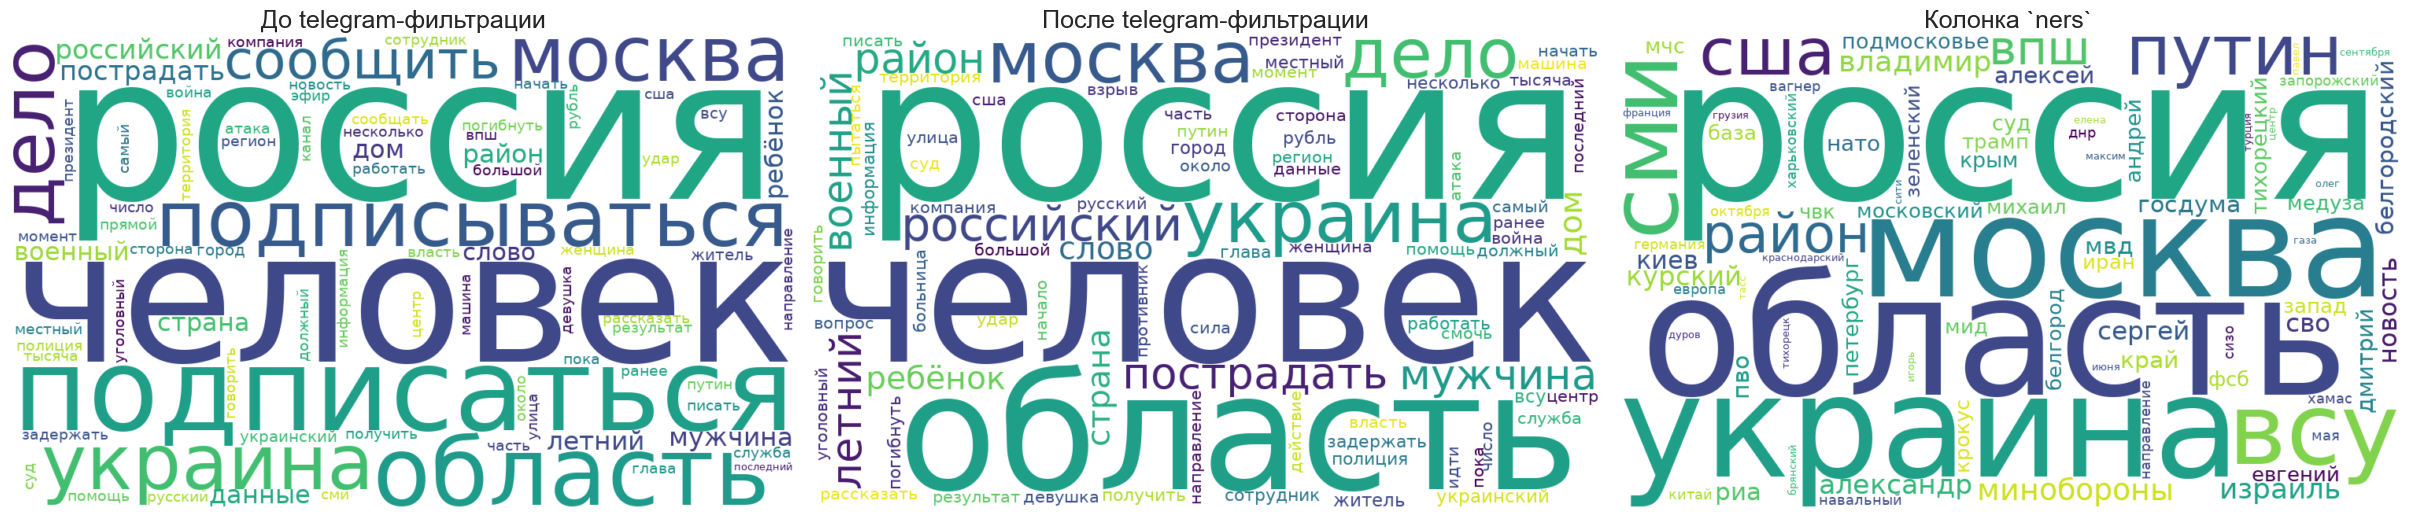

In [29]:


def text_to_counter(series: pd.Series, top_n: int = 80) -> Counter:
    counter = Counter()
    for text in series.fillna(""):
        counter.update(text.split())
    return Counter(dict(counter.most_common(top_n)))


def draw_cloud(ax, frequencies: dict, title: str):
    ax.set_title(title)
    ax.axis("off")
    if not frequencies:
        ax.text(0.5, 0.5, "Нет данных", ha="center", va="center", fontsize=18)
        return

    if HAS_WORDCLOUD:
        cloud = WordCloud(
            width=1000,
            height=600,
            background_color="white",
            colormap="viridis",
            font_path=DEFAULT_FONT,
            random_state=RANDOM_STATE,
        ).generate_from_frequencies(frequencies)
        ax.imshow(cloud, interpolation="bilinear")
        return

    items = sorted(frequencies.items(), key=lambda pair: pair[1], reverse=True)[:50]
    max_freq = max(freq for _, freq in items)
    cols = 5
    rows = int(np.ceil(len(items) / cols))
    coords = [(col, row) for row in range(rows) for col in range(cols)]
    rng = np.random.default_rng(RANDOM_STATE)
    rng.shuffle(coords)
    for (word, freq), (col, row) in zip(items, coords):
        x = (col + 0.5) / cols
        y = 1 - (row + 0.5) / max(rows, 1)
        size = 12 + 26 * (freq / max_freq)
        color = plt.cm.viridis(freq / max_freq)
        ax.text(x, y, word, fontsize=size, color=color, ha="center", va="center", transform=ax.transAxes)


basic_counter = text_to_counter(df["basic_clean_text"])
clean_counter = text_to_counter(df["clean_text"])
ner_counter = text_to_counter(df["ner_lemma_text"])

fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)
draw_cloud(axes[0], basic_counter, "До telegram-фильтрации")
draw_cloud(axes[1], clean_counter, "После telegram-фильтрации")
draw_cloud(axes[2], ner_counter, "Колонка `ners`")
plt.show()



## Тематическое моделирование

Основной вариант:
- `TfidfVectorizer(ngram_range=(1, 2), max_features=5000)`;
- перебор `k` в диапазоне `5..10`;
- оценка по `inertia` и `silhouette score`;
- финальная модель `KMeans`.


In [30]:

if not HAS_UMAP or not HAS_HDBSCAN:
    raise ImportError(
        "Для варианта B нужны пакеты umap-learn и hdbscan. Установите их и перезапустите ноутбук."
    )

def parse_embedding(raw_value):
    if isinstance(raw_value, str):
        arr = np.asarray(ast.literal_eval(raw_value), dtype=np.float32)
    elif isinstance(raw_value, (list, tuple, np.ndarray)):
        arr = np.asarray(raw_value, dtype=np.float32)
    else:
        return None
    return arr if arr.shape == (768,) else None

df["embedding"] = df["vector"].map(parse_embedding)
df = df.loc[df["embedding"].notna()].reset_index(drop=True)
X_embed = np.stack(df["embedding"].to_numpy())
X_embed = normalize(X_embed)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=10, max_df=0.35, sublinear_tf=True)
X_tfidf = vectorizer.fit_transform(df["clean_text"])
feature_names = vectorizer.get_feature_names_out()

print("Размер матрицы эмбеддингов:", X_embed.shape)
print("Размер матрицы TF-IDF (baseline):", X_tfidf.shape)

pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_embed)

umap_reducer = umap.UMAP(
    n_components=15,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
)
X_umap = umap_reducer.fit_transform(X_pca)

min_cluster_grid = [100, 150, 200, 300]
model_metrics = []
for min_cluster_size in min_cluster_grid:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=max(10, min_cluster_size // 10),
        metric="euclidean",
        cluster_selection_method="eom",
    )
    labels = clusterer.fit_predict(X_umap)
    valid_mask = labels != -1
    topic_count = int(np.unique(labels[valid_mask]).size)
    noise_share = float((~valid_mask).mean())
    silhouette = (
        float(silhouette_score(X_umap[valid_mask], labels[valid_mask]))
        if topic_count > 1 and valid_mask.sum() > 100
        else np.nan
    )
    model_metrics.append({"min_cluster_size": min_cluster_size, "topics": topic_count, "noise_share": noise_share, "silhouette": silhouette})

model_selection = pd.DataFrame(model_metrics)
best_row = model_selection.sort_values(["silhouette", "noise_share"], ascending=[False, True], na_position="last").iloc[0]
best_min_cluster_size = int(best_row["min_cluster_size"])
optimal_k = max(int(best_row["topics"]), 2)
model_selection


Размер матрицы эмбеддингов: (89866, 768)
Размер матрицы TF-IDF (baseline): (89866, 5000)


,min_cluster_size,topics,noise_share,silhouette
0,100,91,0.527252,0.431441
1,150,62,0.520831,0.509268
2,200,46,0.521855,0.518260
3,300,31,0.473271,0.487010


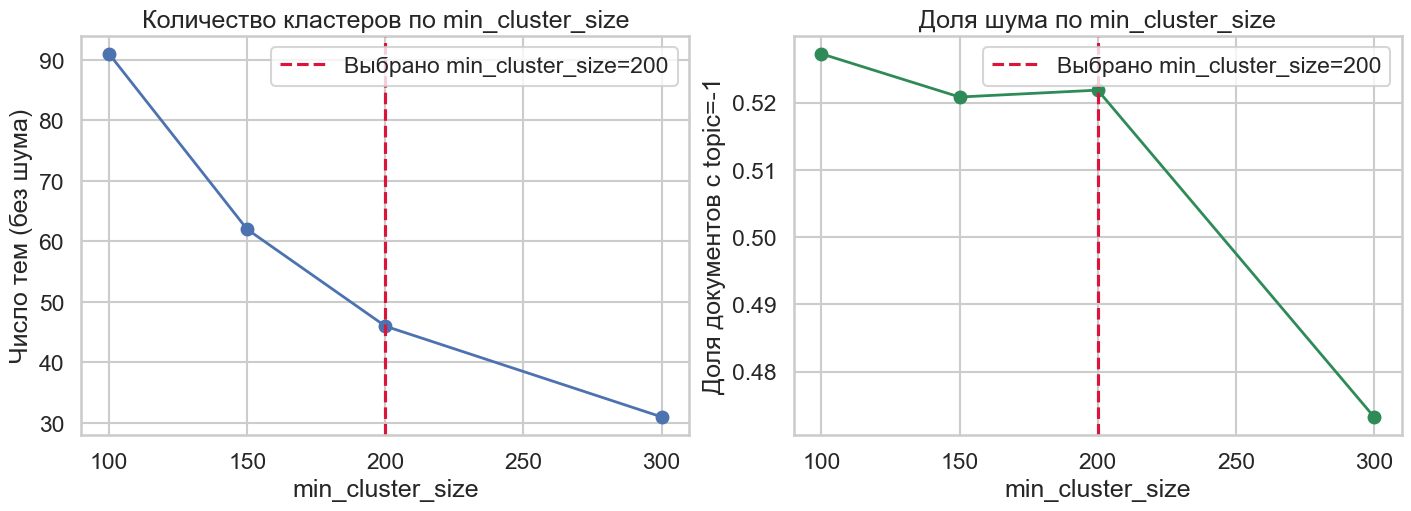

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(model_selection["min_cluster_size"], model_selection["topics"], marker="o", linewidth=2)
axes[0].axvline(best_min_cluster_size, color="crimson", linestyle="--", label=f"Выбрано min_cluster_size={best_min_cluster_size}")
axes[0].set_title("Количество кластеров по min_cluster_size")
axes[0].set_xlabel("min_cluster_size")
axes[0].set_ylabel("Число тем (без шума)")
axes[0].legend()

axes[1].plot(model_selection["min_cluster_size"], model_selection["noise_share"], marker="o", linewidth=2, color="#2E8B57")
axes[1].axvline(best_min_cluster_size, color="crimson", linestyle="--", label=f"Выбрано min_cluster_size={best_min_cluster_size}")
axes[1].set_title("Доля шума по min_cluster_size")
axes[1].set_xlabel("min_cluster_size")
axes[1].set_ylabel("Доля документов с topic=-1")
axes[1].legend()

plt.show()


In [32]:

TOPIC_NAME_EXCLUDE = {"год", "день", "сегодня", "новый", "видео", "место", "время", "работа", "всё", "первый", "хотеть", "заявить", "произойти", "находиться", "появиться"}
GENERIC_TOPIC_WORDS = TOPIC_NAME_EXCLUDE | {"человек", "россия", "российский", "самый", "большой", "хороший", "работать", "страна"}

def topic_label_from_words(words, top_n: int = 3):
    filtered = [word for word in words if word not in TOPIC_NAME_EXCLUDE and " " not in word]
    chosen = filtered[:top_n] if len(filtered) >= top_n else words[:top_n]
    return ", ".join(chosen)

def extract_topic_terms_ctfidf(df_local: pd.DataFrame, topic_col: str = "topic", text_col: str = "clean_text", n_top_words: int = 10):
    topic_ids = sorted(t for t in df_local[topic_col].unique() if t != -1)
    if not topic_ids:
        return {}
    cluster_texts = [" ".join(df_local.loc[df_local[topic_col] == tid, text_col].fillna("").astype(str)) for tid in topic_ids]
    cv = CountVectorizer(max_features=5000, min_df=1)
    X_counts = cv.fit_transform(cluster_texts)
    features = cv.get_feature_names_out()
    transformer = TfidfTransformer(use_idf=True, smooth_idf=True, sublinear_tf=False)
    X_ctfidf = transformer.fit_transform(X_counts)
    topic_terms = {}
    for idx, tid in enumerate(topic_ids):
        scores = np.asarray(X_ctfidf[idx].todense()).ravel()
        top_idx = scores.argsort()[::-1][:n_top_words]
        topic_terms[tid] = [features[j] for j in top_idx]
    return topic_terms

def print_topic_word_lists(topic_terms: dict, model_name: str):
    print(f"=== {model_name} ===")
    for topic_id in sorted(topic_terms):
        print(f"Topic {topic_id}:")
        for word in topic_terms[topic_id]:
            print(f"- {word}")
        print()

def build_topic_artifacts(base_df: pd.DataFrame, model_name: str, doc_topics: np.ndarray, topic_terms: dict, doc_topic_weights: np.ndarray):
    model_df = base_df.copy()
    model_df["topic"] = doc_topics.astype(int)
    topic_name_map = {topic_id: topic_label_from_words(words, top_n=3) for topic_id, words in topic_terms.items()}
    model_df["topic_name"] = model_df["topic"].map(lambda topic_id: f"Topic {topic_id}: {topic_name_map.get(topic_id, 'noise')}")
    topic_examples = []
    for topic_id in sorted(topic_terms):
        topic_docs = model_df.loc[model_df["topic"] == topic_id, ["date", "text", "clean_text"]]
        sample_n = min(5, len(topic_docs))
        sampled = topic_docs.sample(sample_n, random_state=RANDOM_STATE) if sample_n else topic_docs.head(0)
        for rank, (_, row) in enumerate(sampled.iterrows(), start=1):
            topic_examples.append({"model_name": model_name, "topic": topic_id, "topic_name": topic_name_map[topic_id], "example_rank": rank, "date": row["date"], "text": row["text"], "clean_text": row["clean_text"]})
    topic_examples_df = pd.DataFrame(topic_examples)
    topic_summary = pd.DataFrame({
        "model_name": model_name,
        "topic": list(topic_terms.keys()),
        "topic_name": [topic_name_map[topic_id] for topic_id in topic_terms],
        "top_words": [", ".join(topic_terms[topic_id]) for topic_id in topic_terms],
        "documents": [int((model_df["topic"] == topic_id).sum()) for topic_id in topic_terms],
        "sample_texts": [" || ".join(topic_examples_df.loc[topic_examples_df["topic"] == topic_id, "text"].head(5).tolist()) for topic_id in topic_terms],
    }).sort_values("documents", ascending=False).reset_index(drop=True)
    return {"model_name": model_name, "df": model_df, "doc_topics": doc_topics, "doc_topic_weights": doc_topic_weights, "topic_terms": topic_terms, "topic_name_map": topic_name_map, "topic_examples_df": topic_examples_df, "topic_summary": topic_summary}

def mean_top_word_overlap(topic_terms: dict, top_n: int = 10) -> float:
    topic_sets = [set(words[:top_n]) for words in topic_terms.values()]
    overlaps = []
    for idx, left in enumerate(topic_sets):
        for right in topic_sets[idx + 1:]:
            overlaps.append(len(left & right) / max(len(left | right), 1))
    return float(np.mean(overlaps)) if overlaps else 0.0

def unique_top_words_share(topic_terms: dict, top_n: int = 10) -> float:
    all_words = [word for words in topic_terms.values() for word in words[:top_n]]
    return len(set(all_words)) / max(len(all_words), 1)

def generic_topic_share(topic_terms: dict, top_n: int = 10) -> float:
    all_words = [word for words in topic_terms.values() for word in words[:top_n]]
    generic_count = sum(word in GENERIC_TOPIC_WORDS for word in all_words)
    return generic_count / max(len(all_words), 1)

def compute_topic_model_score(artifact: dict) -> dict:
    summary = artifact["topic_summary"]
    doc_topic_weights = artifact["doc_topic_weights"]
    counts = summary["documents"].to_numpy()
    largest_topic_share = counts.max() / counts.sum()
    size_cv = float(np.std(counts) / max(np.mean(counts), 1e-9))
    focus = float(np.mean(doc_topic_weights.max(axis=1)))
    overlap = mean_top_word_overlap(artifact["topic_terms"], top_n=10)
    uniqueness = unique_top_words_share(artifact["topic_terms"], top_n=10)
    generic_share = generic_topic_share(artifact["topic_terms"], top_n=10)
    score = focus + uniqueness - largest_topic_share - overlap - 0.25 * size_cv - 0.5 * generic_share
    return {"model_name": artifact["model_name"], "score": round(score, 4), "largest_topic_share": round(largest_topic_share, 4), "size_cv": round(size_cv, 4), "mean_doc_focus": round(focus, 4), "top_word_overlap": round(overlap, 4), "unique_top_words_share": round(uniqueness, 4), "generic_top_words_share": round(generic_share, 4)}

hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=best_min_cluster_size, min_samples=max(10, best_min_cluster_size // 10), metric="euclidean", cluster_selection_method="eom")
hdbscan_doc_topics = hdbscan_model.fit_predict(X_umap)
semantic_df = df.copy()
semantic_df["topic"] = hdbscan_doc_topics
hdbscan_topic_terms = extract_topic_terms_ctfidf(semantic_df, topic_col="topic", text_col="clean_text", n_top_words=10)
print_topic_word_lists(hdbscan_topic_terms, model_name="HDBSCAN")

valid_topic_ids = [t for t in np.unique(hdbscan_doc_topics) if t != -1]
topic_to_pos = {topic_id: pos for pos, topic_id in enumerate(sorted(valid_topic_ids))}
hdbscan_weights = np.zeros((len(hdbscan_doc_topics), max(len(valid_topic_ids), 1)), dtype=np.float32)
for i, topic in enumerate(hdbscan_doc_topics):
    if topic in topic_to_pos:
        hdbscan_weights[i, topic_to_pos[topic]] = 1.0

SEMANTIC_MODEL_NAME = "HDBSCAN"
topic_artifacts = {SEMANTIC_MODEL_NAME: build_topic_artifacts(df, SEMANTIC_MODEL_NAME, hdbscan_doc_topics, hdbscan_topic_terms, hdbscan_weights)}
topic_artifacts["KMeans"] = topic_artifacts[SEMANTIC_MODEL_NAME]



=== HDBSCAN ===
Topic 0:
- израиль
- хамас
- израильский
- цахать
- хезболл
- иран
- ливан
- сектор
- удар
- газ

Topic 1:
- луна
- мкс
- космический
- земля
- космос
- миссия
- лунный
- орбита
- корабль
- ракета

Topic 2:
- протестовать
- пашинян
- ереван
- протест
- парламент
- тбилиси
- грузия
- человек
- армения
- акция

Topic 3:
- махачкала
- дербент
- дагестан
- человек
- мвд
- боевик
- церковь
- перестрелка
- погибнуть
- полицейский

Topic 4:
- трамп
- байден
- сша
- президент
- харрис
- дональд
- джо
- карлсон
- выборы
- кандидат

Topic 5:
- самолёт
- борт
- аэропорт
- рейс
- пассажир
- пилот
- посадка
- экипаж
- крушение
- авиакомпания

Topic 6:
- курский
- область
- врио
- губернатор
- район
- человек
- регион
- житель
- приграничный
- эвакуация

Topic 7:
- тихорецкий
- тихорецк
- станица
- район
- тихоречанин
- земляк
- поселение
- школа
- весточка
- фастовецкий

Topic 8:
- пригожин
- вагнер
- чвк
- евгений
- уткин
- мятеж
- самолёт
- крушение
- россия
- минобороны

Topic 9:

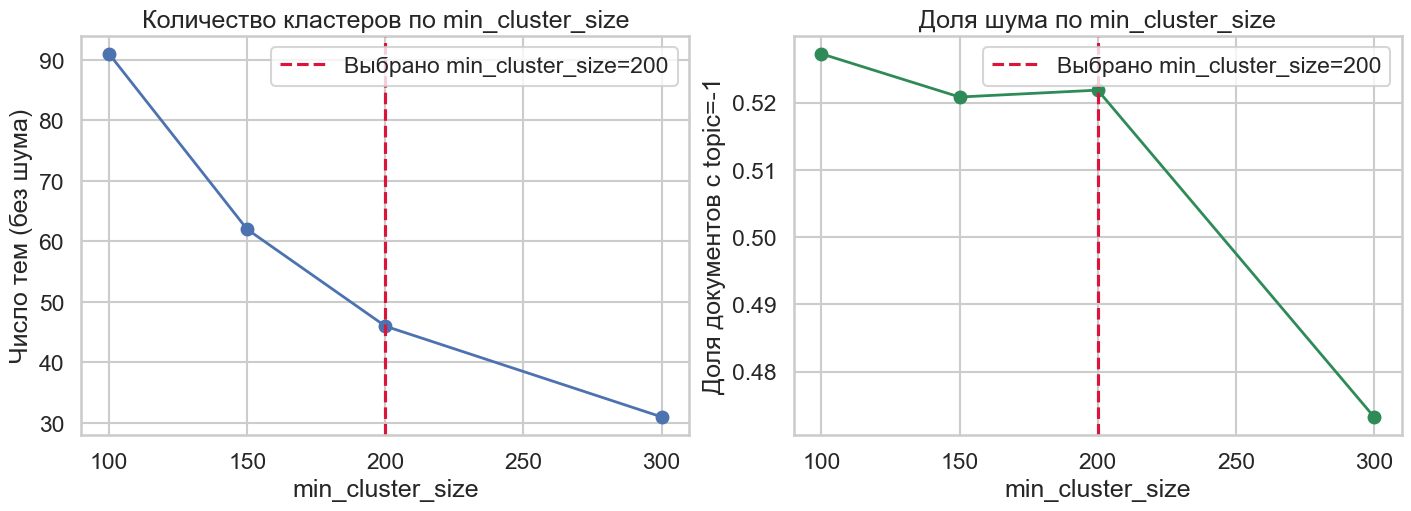

In [33]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].plot(model_selection["min_cluster_size"], model_selection["topics"], marker="o", linewidth=2)
axes[0].axvline(best_min_cluster_size, color="crimson", linestyle="--", label=f"Выбрано min_cluster_size={best_min_cluster_size}")
axes[0].set_title("Количество кластеров по min_cluster_size")
axes[0].set_xlabel("min_cluster_size")
axes[0].set_ylabel("Число тем (без шума)")
axes[0].legend()

axes[1].plot(model_selection["min_cluster_size"], model_selection["noise_share"], marker="o", linewidth=2, color="#2E8B57")
axes[1].axvline(best_min_cluster_size, color="crimson", linestyle="--", label=f"Выбрано min_cluster_size={best_min_cluster_size}")
axes[1].set_title("Доля шума по min_cluster_size")
axes[1].set_xlabel("min_cluster_size")
axes[1].set_ylabel("Доля документов с topic=-1")
axes[1].legend()

plt.show()


In [34]:

TOPIC_NAME_EXCLUDE = {"год", "день", "сегодня", "новый", "видео", "место", "время", "работа", "всё", "первый", "хотеть", "заявить", "произойти", "находиться", "появиться"}
GENERIC_TOPIC_WORDS = TOPIC_NAME_EXCLUDE | {"человек", "россия", "российский", "самый", "большой", "хороший", "работать", "страна"}


def topic_label_from_words(words, top_n: int = 3):
    filtered = [word for word in words if word not in TOPIC_NAME_EXCLUDE and " " not in word]
    chosen = filtered[:top_n] if len(filtered) >= top_n else words[:top_n]
    return ", ".join(chosen)


def extract_topic_terms_from_components(components: np.ndarray, features: np.ndarray, n_top_words: int = 10):
    order = components.argsort(axis=1)[:, ::-1]
    topic_terms = {}
    for topic_id in range(components.shape[0]):
        topic_terms[topic_id] = [features[idx] for idx in order[topic_id, :n_top_words]]
    return topic_terms


def print_topic_word_lists(topic_terms: dict, model_name: str):
    print(f"=== {model_name} ===")
    for topic_id in sorted(topic_terms):
        print(f"Topic {topic_id}:")
        for word in topic_terms[topic_id]:
            print(f"- {word}")
        print()


def build_topic_artifacts(base_df: pd.DataFrame, model_name: str, doc_topics: np.ndarray, topic_terms: dict, doc_topic_weights: np.ndarray):
    model_df = base_df.copy()
    model_df["topic"] = doc_topics.astype(int)
    topic_name_map = {topic_id: topic_label_from_words(words, top_n=3) for topic_id, words in topic_terms.items()}
    model_df["topic_name"] = model_df["topic"].map(lambda topic_id: f"Topic {topic_id}: {topic_name_map.get(topic_id, 'noise')}")

    topic_examples = []
    for topic_id in sorted(topic_terms):
        topic_docs = model_df.loc[model_df["topic"] == topic_id, ["date", "text", "clean_text"]]
        sample_n = min(5, len(topic_docs))
        sampled = topic_docs.sample(sample_n, random_state=RANDOM_STATE) if sample_n else topic_docs.head(0)
        for rank, (_, row) in enumerate(sampled.iterrows(), start=1):
            topic_examples.append(
                {
                    "model_name": model_name,
                    "topic": topic_id,
                    "topic_name": topic_name_map[topic_id],
                    "example_rank": rank,
                    "date": row["date"],
                    "text": row["text"],
                    "clean_text": row["clean_text"],
                }
            )

    topic_examples_df = pd.DataFrame(topic_examples)
    topic_summary = pd.DataFrame(
        {
            "model_name": model_name,
            "topic": list(topic_terms.keys()),
            "topic_name": [topic_name_map[topic_id] for topic_id in topic_terms],
            "top_words": [", ".join(topic_terms[topic_id]) for topic_id in topic_terms],
            "documents": [int((model_df["topic"] == topic_id).sum()) for topic_id in topic_terms],
            "sample_texts": [
                " || ".join(topic_examples_df.loc[topic_examples_df["topic"] == topic_id, "text"].head(5).tolist())
                for topic_id in topic_terms
            ],
        }
    ).sort_values("documents", ascending=False).reset_index(drop=True)

    return {
        "model_name": model_name,
        "df": model_df,
        "doc_topics": doc_topics,
        "doc_topic_weights": doc_topic_weights,
        "topic_terms": topic_terms,
        "topic_name_map": topic_name_map,
        "topic_examples_df": topic_examples_df,
        "topic_summary": topic_summary,
    }


def mean_top_word_overlap(topic_terms: dict, top_n: int = 10) -> float:
    topic_sets = [set(words[:top_n]) for words in topic_terms.values()]
    overlaps = []
    for idx, left in enumerate(topic_sets):
        for right in topic_sets[idx + 1:]:
            overlaps.append(len(left & right) / max(len(left | right), 1))
    return float(np.mean(overlaps)) if overlaps else 0.0


def unique_top_words_share(topic_terms: dict, top_n: int = 10) -> float:
    all_words = [word for words in topic_terms.values() for word in words[:top_n]]
    return len(set(all_words)) / max(len(all_words), 1)


def generic_topic_share(topic_terms: dict, top_n: int = 10) -> float:
    all_words = [word for words in topic_terms.values() for word in words[:top_n]]
    generic_count = sum(word in GENERIC_TOPIC_WORDS for word in all_words)
    return generic_count / max(len(all_words), 1)


def compute_topic_model_score(artifact: dict) -> dict:
    summary = artifact["topic_summary"]
    doc_topic_weights = artifact["doc_topic_weights"]
    counts = summary["documents"].to_numpy()
    largest_topic_share = counts.max() / counts.sum()
    size_cv = float(np.std(counts) / max(np.mean(counts), 1e-9))
    focus = float(np.mean(doc_topic_weights.max(axis=1)))
    overlap = mean_top_word_overlap(artifact["topic_terms"], top_n=10)
    uniqueness = unique_top_words_share(artifact["topic_terms"], top_n=10)
    generic_share = generic_topic_share(artifact["topic_terms"], top_n=10)
    score = focus + uniqueness - largest_topic_share - overlap - 0.25 * size_cv - 0.5 * generic_share
    return {
        "model_name": artifact["model_name"],
        "score": round(score, 4),
        "largest_topic_share": round(largest_topic_share, 4),
        "size_cv": round(size_cv, 4),
        "mean_doc_focus": round(focus, 4),
        "top_word_overlap": round(overlap, 4),
        "unique_top_words_share": round(uniqueness, 4),
        "generic_top_words_share": round(generic_share, 4),
    }


hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=best_min_cluster_size, min_samples=max(10, best_min_cluster_size // 10), metric="euclidean", cluster_selection_method="eom")
hdbscan_doc_topics = hdbscan_model.fit_predict(X_umap)
semantic_df = df.copy()
semantic_df["topic"] = hdbscan_doc_topics
hdbscan_topic_terms = extract_topic_terms_ctfidf(semantic_df, topic_col="topic", text_col="clean_text", n_top_words=10)
print_topic_word_lists(hdbscan_topic_terms, model_name="HDBSCAN")

valid_topic_ids = [t for t in np.unique(hdbscan_doc_topics) if t != -1]
topic_to_pos = {topic_id: pos for pos, topic_id in enumerate(sorted(valid_topic_ids))}
hdbscan_weights = np.zeros((len(hdbscan_doc_topics), max(len(valid_topic_ids), 1)), dtype=np.float32)
for i, topic in enumerate(hdbscan_doc_topics):
    if topic in topic_to_pos:
        hdbscan_weights[i, topic_to_pos[topic]] = 1.0

SEMANTIC_MODEL_NAME = "HDBSCAN"
topic_artifacts = {SEMANTIC_MODEL_NAME: build_topic_artifacts(df, SEMANTIC_MODEL_NAME, hdbscan_doc_topics, hdbscan_topic_terms, hdbscan_weights)}
topic_artifacts["KMeans"] = topic_artifacts[SEMANTIC_MODEL_NAME]


=== HDBSCAN ===
Topic 0:
- израиль
- хамас
- израильский
- цахать
- хезболл
- иран
- ливан
- сектор
- удар
- газ

Topic 1:
- луна
- мкс
- космический
- земля
- космос
- миссия
- лунный
- орбита
- корабль
- ракета

Topic 2:
- протестовать
- пашинян
- ереван
- протест
- парламент
- тбилиси
- грузия
- человек
- армения
- акция

Topic 3:
- махачкала
- дербент
- дагестан
- человек
- мвд
- боевик
- церковь
- перестрелка
- погибнуть
- полицейский

Topic 4:
- трамп
- байден
- сша
- президент
- харрис
- дональд
- джо
- карлсон
- выборы
- кандидат

Topic 5:
- самолёт
- борт
- аэропорт
- рейс
- пассажир
- пилот
- посадка
- экипаж
- крушение
- авиакомпания

Topic 6:
- курский
- область
- врио
- губернатор
- район
- человек
- регион
- житель
- приграничный
- эвакуация

Topic 7:
- тихорецкий
- тихорецк
- станица
- район
- тихоречанин
- земляк
- поселение
- школа
- весточка
- фастовецкий

Topic 8:
- пригожин
- вагнер
- чвк
- евгений
- уткин
- мятеж
- самолёт
- крушение
- россия
- минобороны

Topic 9:

In [35]:

kmeans_topic_summary = topic_artifacts["KMeans"]["topic_summary"]
kmeans_topic_examples = topic_artifacts["KMeans"]["topic_examples_df"]

kmeans_topic_summary


,model_name,topic,topic_name,top_words,documents,sample_texts
0,HDBSCAN,25,"украина, россия, путин","украина, россия, путин, страна, нато, президент, саммит, зеленский, сша, брикс",5334,"Владимир Путин заявил, что рожать детей следует пораньше, чтобы обеспечить рост населения\nВПШ\n🐍 || Главное из брифинга представителя М..."
1,HDBSCAN,16,"пожар, взрыв, человек","пожар, взрыв, человек, пострадать, возгорание, дом, погибнуть, гореть, здание, мчс",2229,"Фотографии изнутри квартиры, где прогремел взрыв в Химках. Количество пострадавших возросло до семи человек.\nСледственный комитет возбу..."
2,HDBSCAN,41,"мужчина, пострадать, человек","мужчина, пострадать, человек, водитель, машина, дтп, авария, автобус, москва, пассажир",2203,Вооруженный мужчина захватил травпункт на Стромынке.\nПо словам очевидцев из поликлиники выбегают люди. На место едут сотрудники полиции...
3,HDBSCAN,5,"самолёт, борт, аэропорт","самолёт, борт, аэропорт, рейс, пассажир, пилот, посадка, экипаж, крушение, авиакомпания",2082,Аэропорт Шереметьево не выпускает некоторые самолеты из-за угрозы атаки БПЛА в Нижегородской области и Татарстане – источник 112. || Фот...
4,HDBSCAN,7,"тихорецкий, тихорецк, станица","тихорецкий, тихорецк, станица, район, тихоречанин, земляк, поселение, школа, весточка, фастовецкий",2067,Губернатор Кубани поздравил тихоречанок с победами\n22 июня в Армавире стартовал финал XI летней Спартакиады учащихся России по самбо.\n...
5,HDBSCAN,27,"госдума, законопроект, россия","госдума, законопроект, россия, закон, ребёнок, запрет, депутат, принять, страна, гражданин",1970,"Зампред Госдумы по экономической политике заявил, что России якобы нечего предложить гражданам, «кроме песни Шамана», а ребенок — билет ..."
6,HDBSCAN,0,"израиль, хамас, израильский","израиль, хамас, израильский, цахать, хезболл, иран, ливан, сектор, удар, газ",1932,"❗️\nИзраиль близок к принятию решения по Ливану, в случае полномасштабной войны ""Хезболлах"" будет уничтожена, сообщает глава израильског..."
7,HDBSCAN,37,"летний, девочка, ребёнок","летний, девочка, ребёнок, школа, мужчина, школьница, женщина, полиция, мальчик, мать",1873,"Триллер из Ленобласти: женщина зарезала возлюбленного и месяц жила с его трупом. Она пустилась в бега, только когда тело стало разлагать..."
8,HDBSCAN,19,"противник, враг, дрон","противник, враг, дрон, боец, фронтовой, подразделение, боевой, позиция, фронт, помощь",1457,"👼\nНаше уничтожение скопившегося противника в кучке, видимо ждали подъезд техники но не успели.\nАрхангел Спецназа. Подписаться. || Докл..."
9,HDBSCAN,23,"крокус, теракт, холл","крокус, теракт, холл, сити, террорист, человек, заложник, сотрудник, погибнуть, зал",1363,"Губернатор Воробьев рассказал о ходе\nразбора завалов в ""Крокусе""\n📢\nПрямой эфир - подписаться || В суд доставлен девятый фигурант дела..."



## NMF Тематическое Моделирование

`NMF` обучается на той же `TF-IDF` матрице и с тем же числом тем, что и `KMeans`. Это позволяет сравнивать модели на одном и том же корпусе без смещения из-за разных признаков или другого `k`.


In [36]:

nmf_model = NMF(n_components=optimal_k, init="nndsvda", random_state=RANDOM_STATE, max_iter=400)
nmf_doc_topic_weights = nmf_model.fit_transform(X_tfidf)
nmf_doc_topics = nmf_doc_topic_weights.argmax(axis=1)
nmf_topic_terms = extract_topic_terms_from_components(nmf_model.components_, feature_names, n_top_words=10)
print_topic_word_lists(nmf_topic_terms, model_name="NMF")

topic_artifacts["NMF"] = build_topic_artifacts(df, "NMF", nmf_doc_topics, nmf_topic_terms, nmf_doc_topic_weights)
nmf_topic_summary = topic_artifacts["NMF"]["topic_summary"]
nmf_topic_examples = topic_artifacts["NMF"]["topic_examples_df"]

nmf_topic_summary


=== NMF ===
Topic 0:
- просто
- большой
- слово
- рассказать
- говорить
- сделать
- жизнь
- решить
- хороший
- русский

Topic 1:
- область
- белгородский
- белгородский область
- губернатор
- гладков
- регион
- обстрел
- село
- брянский
- брянский область

Topic 2:
- украина
- зеленский
- киев
- украинский
- нато
- война
- страна
- переговоры
- конфликт
- оружие

Topic 3:
- дело
- уголовный
- уголовный дело
- возбудить
- возбудить уголовный
- статья
- дело статья
- отношение
- факт
- грозить

Topic 4:
- противник
- направление
- запорожский
- запорожский направление
- бой
- позиция
- всу
- враг
- артиллерия
- идти

Topic 5:
- москва
- центр
- центр москва
- москвача
- собянин
- москва сити
- улица
- сити
- столица
- суд москва

Topic 6:
- глава
- министр
- регион
- мид
- глава мид
- премьер
- глава регион
- республика
- пост
- правительство

Topic 7:
- рубль
- тысяча
- тысяча рубль
- млн
- миллион
- млн рубль
- миллион рубль
- доллар
- цена
- деньга

Topic 8:
- человек
- погибнуть
- че

,model_name,topic,topic_name,top_words,documents,sample_texts
0,NMF,45,"госдума, закон, депутат","госдума, закон, депутат, принять, законопроект, запрет, внести, госдума принять, иноагент, депутат госдума",3919,"Верховная рада Украины приняла в первом чтении законопроект о медицинском каннабисе. 268 депутатов проголосовали за документ, 17 — проти..."
1,NMF,29,"компания, пользователь, сервис","компания, пользователь, сервис, приложение, сбой, банк, сайт, работать, карта, проблема",3879,Сайт СДЭК частично восстановил работу после хакерской атаки\nОб этом сообщается на главной странице веб-ресурса оператора доставки докум...
2,NMF,42,"информация, пока, официальный","информация, пока, официальный, источник, информация пострадать, официальный информация, предварительный информация, писать, информация п...",3777,Зеленский отрицает слухи о возможном увольнении главы разведки Буданова и главы Минобороны Умерова.\n«Я не собирался этого делать. Я не ...
3,NMF,25,"суд, арестовать, дело","суд, арестовать, дело, признать, арест, колония, обвинять, приговорить, следствие, суд москва",3756,"Парламент Германии проголосовал\nза смягчение уголовного наказания за хранение детской порнографии\nШизоиды, называющие себя\nактивистам..."
4,NMF,35,"сша, президент, трамп","сша, президент, трамп, байден, выборы, американский, президент сша, кандидат, дональд, джо",3175,"Возле гольф-клуба Трампа в городе Уэст-Палм-Бич в штате Флорида произошла стрельба, два человека стреляли друг в друга, а не в Трампа — ..."
5,NMF,44,"самый, мир, популярный","самый, мир, популярный, история, хороший, самый популярный, цена, милый, дорогой, больший",3067,Сеть киберспортивных клубов True Gamers создаст первый в мире киберспортивный остров в Абу–Даби с тренировочной базой и заселением в оте...
6,NMF,38,"город, центр, мэр","город, центр, мэр, улица, власть, центр город, часть, мэр город, администрация, петербург",3042,"Неопознанный объект\nнашли на берегу возле японского города Хамамацу. Полиция даже оцепила местный пляж.\nШары\n, пощадите!\nПодписаться..."
7,NMF,31,"задержать, сотрудник, полиция","задержать, сотрудник, полиция, полицейский, сотрудник полиция, подозревать, мвд, отдел, стрельба, силовик",2994,"Пассажира,\nизбившего водителя такси\n, задержали в Тульской области. Он задержан за хулиганство. По данным МВД, мужчина ранее неоднокра..."
8,NMF,36,"житель, местный, власть","житель, местный, местный житель, власть, мирный, мирный житель, местный власть, вода, слово местный, писать",2787,"Жители Суровикино сообщают в местных чатах, что слышат звуки стрельбы. Незадолго до этого в городе начали глушить связь. || ФСБ опублико..."
9,NMF,20,"тихорецкий, друг, вместе","тихорецкий, друг, тихорецкий район, вместе, край, добрый, тихорецк, пройти, краснодарский, станица",2774,"Репост добра\n🙏\nПоможем хвостатому найти хозяев, друзья\n❤️\n? В морозы ему не выжить без нашей помощи\n😢\n""Тихорецкие вести"" - с вами ..."



## Сравнение KMeans И NMF

Ниже сравниваются две модели на одном и том же датасете. Используются внутренние proxy-метрики качества тем:
- перекос самого большого топика;
- разброс размеров тем;
- сфокусированность распределения документов по темам;
- пересечение топ-слов между темами;
- доля слишком общих слов в топ-словах.

Модель с лучшим суммарным score используется дальше в блоках динамики и прогнозирования.


In [37]:

topic_model_comparison = pd.DataFrame(
    [compute_topic_model_score(topic_artifacts[model_name]) for model_name in ["KMeans", "NMF"]]
).sort_values("score", ascending=False).reset_index(drop=True)

comparison_preview = pd.concat(
    [
        topic_artifacts[model_name]["topic_summary"].assign(topic_model=model_name).head(5)
        for model_name in ["KMeans", "NMF"]
    ],
    ignore_index=True,
)

SELECTED_TOPIC_MODEL = topic_model_comparison.iloc[0]["model_name"]
selected_artifacts = topic_artifacts[SELECTED_TOPIC_MODEL]

df = selected_artifacts["df"].copy()
topic_terms = selected_artifacts["topic_terms"]
topic_name_map = selected_artifacts["topic_name_map"]
topic_examples_df = selected_artifacts["topic_examples_df"].copy()
topic_summary = selected_artifacts["topic_summary"].copy()
topic_summary["topic_model"] = SELECTED_TOPIC_MODEL

print(f"Выбрана модель тем: {SELECTED_TOPIC_MODEL}")
display(topic_model_comparison)
display(comparison_preview[["topic_model", "topic", "topic_name", "documents", "top_words"]])


Выбрана модель тем: HDBSCAN


,model_name,score,largest_topic_share,size_cv,mean_doc_focus,top_word_overlap,unique_top_words_share,generic_top_words_share
0,HDBSCAN,0.8385,0.1241,0.9585,0.4781,0.0128,0.7630,0.0522
1,NMF,0.7596,0.0436,0.4820,0.0319,0.0027,0.9065,0.0239


,topic_model,topic,topic_name,documents,top_words
0,KMeans,25,"украина, россия, путин",5334,"украина, россия, путин, страна, нато, президент, саммит, зеленский, сша, брикс"
1,KMeans,16,"пожар, взрыв, человек",2229,"пожар, взрыв, человек, пострадать, возгорание, дом, погибнуть, гореть, здание, мчс"
2,KMeans,41,"мужчина, пострадать, человек",2203,"мужчина, пострадать, человек, водитель, машина, дтп, авария, автобус, москва, пассажир"
3,KMeans,5,"самолёт, борт, аэропорт",2082,"самолёт, борт, аэропорт, рейс, пассажир, пилот, посадка, экипаж, крушение, авиакомпания"
4,KMeans,7,"тихорецкий, тихорецк, станица",2067,"тихорецкий, тихорецк, станица, район, тихоречанин, земляк, поселение, школа, весточка, фастовецкий"
5,NMF,45,"госдума, закон, депутат",3919,"госдума, закон, депутат, принять, законопроект, запрет, внести, госдума принять, иноагент, депутат госдума"
6,NMF,29,"компания, пользователь, сервис",3879,"компания, пользователь, сервис, приложение, сбой, банк, сайт, работать, карта, проблема"
7,NMF,42,"информация, пока, официальный",3777,"информация, пока, официальный, источник, информация пострадать, официальный информация, предварительный информация, писать, информация п..."
8,NMF,25,"суд, арестовать, дело",3756,"суд, арестовать, дело, признать, арест, колония, обвинять, приговорить, следствие, суд москва"
9,NMF,35,"сша, президент, трамп",3175,"сша, президент, трамп, байден, выборы, американский, президент сша, кандидат, дональд, джо"



## Optional: LDA для сравнения

Это дополнительный блок для грубого сравнения с кластеризацией `KMeans`. `Coherence` считается только если в окружении доступен `gensim`; иначе выводится уведомление.


In [38]:

try:
    from gensim.corpora import Dictionary
    from gensim.models import CoherenceModel
    HAS_GENSIM = True
except ImportError:
    Dictionary = None
    CoherenceModel = None
    HAS_GENSIM = False

lda_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=3000)
X_lda = lda_vectorizer.fit_transform(df["clean_text"])
lda_model = LatentDirichletAllocation(n_components=optimal_k, random_state=RANDOM_STATE, learning_method="batch")
lda_model.fit(X_lda)
lda_feature_names = lda_vectorizer.get_feature_names_out()

lda_topics = {}
for topic_id, topic_weights in enumerate(lda_model.components_):
    top_indices = topic_weights.argsort()[::-1][:10]
    lda_topics[topic_id] = [lda_feature_names[idx] for idx in top_indices]

if HAS_GENSIM:
    tokenized_docs = [text.split() for text in df["clean_text"].head(50000)]
    dictionary = Dictionary(tokenized_docs)
    coherence_model = CoherenceModel(
        topics=[lda_topics[topic_id] for topic_id in sorted(lda_topics)],
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v",
    )
    lda_coherence = coherence_model.get_coherence()
    print(f"LDA coherence (c_v): {lda_coherence:.4f}")
else:
    lda_coherence = None
    print("gensim не установлен: coherence для LDA пропущен")

pd.DataFrame({
    "topic": list(lda_topics.keys()),
    "top_words": [", ".join(lda_topics[i]) for i in sorted(lda_topics)],
})


gensim не установлен: coherence для LDA пропущен


,topic,top_words
0,0,"полиция, мужчина, сотрудник, летний, полицейский, скорый, москва, пострадать, парень, помощь"
1,1,"врач, больница, состояние, пора, сей, сей пора, медик, госпитализировать, операция, летний"
2,2,"дело, уголовный, уголовный дело, возбудить, статья, задержать, возбудить уголовный, летний, грозить, колония"
3,3,"служба, теракт, крокус, пресс, навальный, террорист, пресс служба, алексей, теракт крокус, зона"
4,4,"тихорецкий, район, программа, курс, край, тихорецкий район, глава, участие, проект, тихорецк"
5,5,"москва, петербург, санкт, санкт петербург, столица, неделя, ожидаться, температура, выходной, дождь"
6,6,"принять, идти, решение, регион, речь, речь идти, северный, тыс, россия, принять решение"
7,7,"суд, дело, арест, адвокат, арестовать, обвинение, сизый, кадыров, москва, обвинять"
8,8,"школа, школьник, взрыв, класс, учитель, ученик, учебный, урок, подросток, мэр"
9,9,"закон, госдума, запрет, законопроект, карта, депутат, россия, запретить, принять, внести"



## Анализ динамики

Для каждой темы строится временной ряд по дням, затем выполняется проверка непрерывности и добавляется опциональное сглаживание `rolling(window=7).mean()`.


In [39]:

topic_daily = df.groupby(["day", "topic"]).size().unstack(fill_value=0).sort_index()
min_date = topic_daily.index.min()
max_date = topic_daily.index.max()
date_range = pd.date_range(min_date, max_date, freq="D")
topic_daily = topic_daily.reindex(date_range, fill_value=0)
topic_daily.index.name = "day"
topic_daily.columns = [f"topic_{topic_id}" for topic_id in topic_daily.columns]
topic_lookup = {f"topic_{topic_id}": f"Topic {topic_id}: {topic_name_map[topic_id]}" for topic_id in topic_terms}

topic_daily_smoothed = topic_daily.rolling(window=7, min_periods=1).mean()

topic_daily.head()


,topic_-1,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,...,topic_36,topic_37,topic_38,topic_39,topic_40,topic_41,topic_42,topic_43,topic_44,topic_45
day,,,,,,,,,,,,,,,,,,,,,
2020-06-12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-06-13,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2020-06-14,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-06-15,8,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,4,1,0,0,0
2020-06-16,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


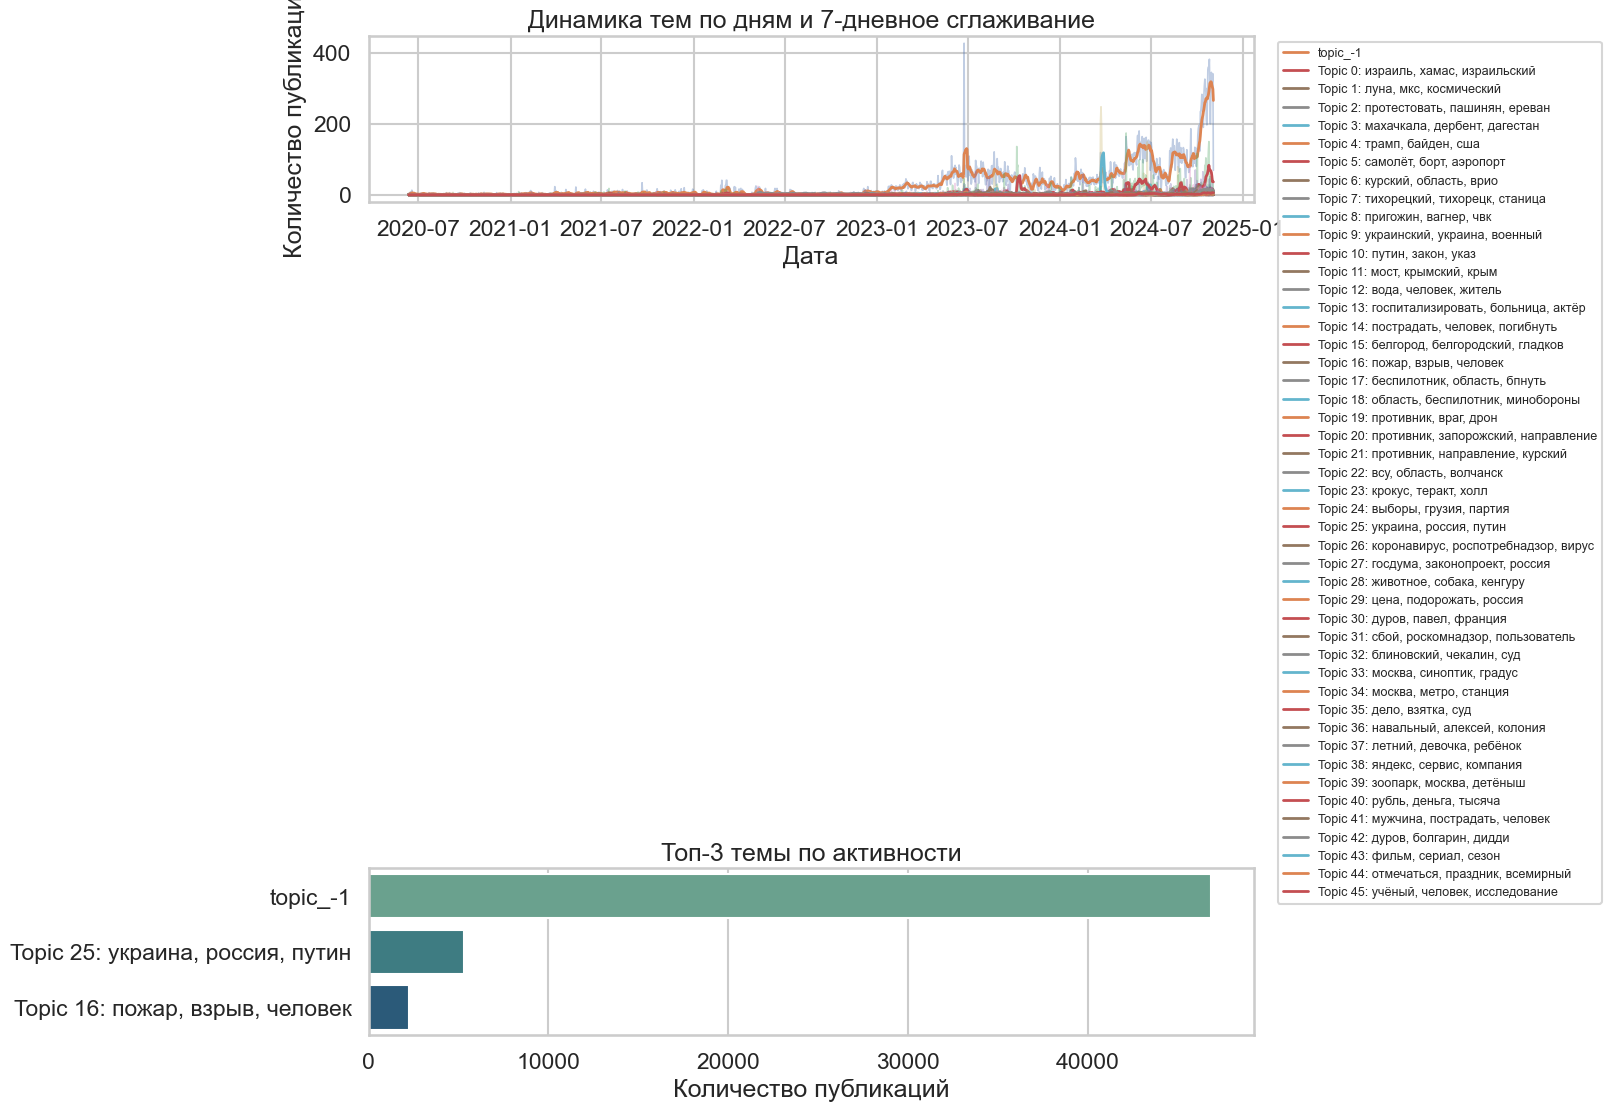

In [40]:

topic_totals = topic_daily.sum().sort_values(ascending=False)
top3_topics = topic_totals.head(3).index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(16, 11), constrained_layout=True)
for col in topic_daily.columns:
    axes[0].plot(topic_daily.index, topic_daily[col], linewidth=1.2, alpha=0.35)
    axes[0].plot(topic_daily_smoothed.index, topic_daily_smoothed[col], linewidth=2, label=topic_lookup.get(col, col))
axes[0].set_title("Динамика тем по дням и 7-дневное сглаживание")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Количество публикаций")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=9)

bar_data = pd.DataFrame({
    "topic": [topic_lookup.get(col, col) for col in top3_topics],
    "posts": topic_totals.loc[top3_topics].values,
})
if HAS_SEABORN:
    sns.barplot(data=bar_data, x="posts", y="topic", ax=axes[1], palette="crest")
else:
    axes[1].barh(bar_data["topic"], bar_data["posts"], color="#4C78A8")
axes[1].set_title("Топ-3 темы по активности")
axes[1].set_xlabel("Количество публикаций")
axes[1].set_ylabel("")

plt.show()



## Детекция событий

Для каждой темы рассчитываются:
- `growth_rate = series.diff()`;
- `event_score = volume + growth_rate`;
- топ-5 пиков по объёму публикаций.


In [41]:

event_rows = []
peak_rows = []
trend_rows = []

for col in topic_daily.columns:
    series = topic_daily[col].astype(float)
    growth_rate = series.diff().fillna(0)
    event_score_series = series + growth_rate
    peaks = series.nlargest(5)

    mean_value = series.mean()
    last_mean = series.tail(14).mean()
    prev_mean = series.iloc[-28:-14].mean() if len(series) >= 28 else series.head(14).mean()
    if last_mean > prev_mean * 1.1:
        trend = "растет"
    elif last_mean < prev_mean * 0.9:
        trend = "падает"
    else:
        trend = "стабилен"

    trend_rows.append(
        {
            "topic": col,
            "topic_name": topic_lookup.get(col, col),
            "mean_value": round(mean_value, 3),
            "trend": trend,
            "peak_date": series.idxmax().date(),
            "peak_value": int(series.max()),
        }
    )

    for peak_rank, (peak_date, peak_value) in enumerate(peaks.items(), start=1):
        peak_rows.append(
            {
                "topic": col,
                "topic_name": topic_lookup.get(col, col),
                "peak_rank": peak_rank,
                "peak_date": peak_date.date(),
                "peak_value": int(peak_value),
            }
        )

    event_rows.append(
        {
            "topic": col,
            "topic_name": topic_lookup.get(col, col),
            "recent_volume": round(series.tail(14).mean(), 3),
            "recent_growth_rate": round(growth_rate.tail(14).mean(), 3),
            "event_score": round(event_score_series.tail(14).mean(), 3),
        }
    )

event_scores = pd.DataFrame(event_rows).sort_values("event_score", ascending=False).reset_index(drop=True)
peak_df = pd.DataFrame(peak_rows)
trend_df = pd.DataFrame(trend_rows)

display(event_scores.head(10))
display(peak_df.head(10))


,topic,topic_name,recent_volume,recent_growth_rate,event_score
0,topic_-1,topic_-1,290.214,-9.929,280.286
1,topic_25,"Topic 25: украина, россия, путин",53.714,-1.714,52.000
2,topic_0,"Topic 0: израиль, хамас, израильский",13.357,-1.357,12.000
3,topic_42,"Topic 42: дуров, болгарин, дидди",12.429,-0.500,11.929
4,topic_41,"Topic 41: мужчина, пострадать, человек",9.857,-0.143,9.714
5,topic_27,"Topic 27: госдума, законопроект, россия",9.357,-0.286,9.071
6,topic_5,"Topic 5: самолёт, борт, аэропорт",9.214,-0.214,9.000
7,topic_24,"Topic 24: выборы, грузия, партия",8.929,0.000,8.929
8,topic_19,"Topic 19: противник, враг, дрон",8.143,-0.500,7.643
9,topic_35,"Topic 35: дело, взятка, суд",7.286,0.214,7.500


,topic,topic_name,peak_rank,peak_date,peak_value
0,topic_-1,topic_-1,1,2023-06-24,427
1,topic_-1,topic_-1,2,2024-10-25,382
2,topic_-1,topic_-1,3,2024-10-23,360
3,topic_-1,topic_-1,4,2024-10-24,358
4,topic_-1,topic_-1,5,2024-10-22,354
5,topic_0,"Topic 0: израиль, хамас, израильский",1,2023-10-07,136
6,topic_0,"Topic 0: израиль, хамас, израильский",2,2024-10-01,117
7,topic_0,"Topic 0: израиль, хамас, израильский",3,2023-10-09,84
8,topic_0,"Topic 0: израиль, хамас, израильский",4,2023-10-08,77
9,topic_0,"Topic 0: израиль, хамас, израильский",5,2024-04-13,55



## Прогнозирование

Сравниваются три модели:
- `Naive baseline`;
- `ARIMA`;
- `Prophet`.

Для каждой темы считается `MAE` и `RMSE` на тестовом интервале `20%`.


In [42]:

TEST_FRACTION = 0.2
MIN_TEST_SIZE = 14
ARIMA_ORDER = (1, 1, 1)


def split_series(series: pd.Series, test_fraction: float = TEST_FRACTION, min_test_size: int = MIN_TEST_SIZE):
    n_test = max(min_test_size, int(len(series) * test_fraction))
    n_test = min(n_test, max(1, len(series) // 3))
    train = series.iloc[:-n_test]
    test = series.iloc[-n_test:]
    return train, test


def compute_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return mae, rmse


def naive_forecast(train: pd.Series, test: pd.Series) -> np.ndarray:
    return np.repeat(train.iloc[-1], len(test))


def arima_forecast(train: pd.Series, horizon: int, order=ARIMA_ORDER) -> np.ndarray:
    if not HAS_STATSMODELS:
        raise ImportError("statsmodels не установлен")
    if train.nunique() <= 1:
        return np.repeat(train.iloc[-1], horizon)
    model = ARIMA(train.astype(float), order=order)
    fitted = model.fit()
    forecast = fitted.forecast(steps=horizon)
    return np.asarray(forecast)


def prophet_forecast(train: pd.Series, horizon: int) -> np.ndarray:
    if not HAS_PROPHET:
        raise ImportError("prophet не установлен")
    prophet_train = train.reset_index()
    prophet_train.columns = ["ds", "y"]
    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(prophet_train)
    future = model.make_future_dataframe(periods=horizon, freq="D", include_history=False)
    forecast = model.predict(future)
    return forecast["yhat"].to_numpy()


metrics_rows = []
forecast_store = {}

for col in topic_daily.columns:
    series = topic_daily[col].astype(float)
    if len(series) < 30 or series.sum() == 0:
        continue

    train, test = split_series(series)
    naive_pred = np.clip(naive_forecast(train, test), 0, None)
    naive_mae, naive_rmse = compute_metrics(test, naive_pred)
    metrics_rows.append({"topic": col, "topic_name": topic_lookup.get(col, col), "model": "Naive", "MAE": round(naive_mae, 3), "RMSE": round(naive_rmse, 3)})
    forecast_store[(col, "Naive")] = {"train": train, "test": test, "pred": naive_pred}

    try:
        arima_pred = np.clip(arima_forecast(train, len(test)), 0, None)
    except Exception:
        arima_pred = np.repeat(train.iloc[-1], len(test))
    arima_mae, arima_rmse = compute_metrics(test, arima_pred)
    metrics_rows.append({"topic": col, "topic_name": topic_lookup.get(col, col), "model": "ARIMA", "MAE": round(arima_mae, 3), "RMSE": round(arima_rmse, 3)})
    forecast_store[(col, "ARIMA")] = {"train": train, "test": test, "pred": arima_pred}

    if HAS_PROPHET:
        try:
            prophet_pred = np.clip(prophet_forecast(train, len(test)), 0, None)
            prophet_mae, prophet_rmse = compute_metrics(test, prophet_pred)
            metrics_rows.append({"topic": col, "topic_name": topic_lookup.get(col, col), "model": "Prophet", "MAE": round(prophet_mae, 3), "RMSE": round(prophet_rmse, 3)})
            forecast_store[(col, "Prophet")] = {"train": train, "test": test, "pred": prophet_pred}
        except Exception as exc:
            print(f"Prophet не смог обучиться для {col}: {exc}")

metrics_df = pd.DataFrame(metrics_rows)
comparison_table = metrics_df.pivot_table(index="topic_name", columns="model", values=["MAE", "RMSE"])
comparison_table


18:38:36 - cmdstanpy - INFO - Chain [1] start processing
18:38:36 - cmdstanpy - INFO - Chain [1] done processing
18:38:36 - cmdstanpy - INFO - Chain [1] start processing
18:38:36 - cmdstanpy - INFO - Chain [1] done processing
18:38:36 - cmdstanpy - INFO - Chain [1] start processing
18:38:37 - cmdstanpy - INFO - Chain [1] done processing
18:38:37 - cmdstanpy - INFO - Chain [1] start processing
18:38:37 - cmdstanpy - INFO - Chain [1] done processing
18:38:37 - cmdstanpy - INFO - Chain [1] start processing
18:38:37 - cmdstanpy - INFO - Chain [1] done processing
18:38:37 - cmdstanpy - INFO - Chain [1] start processing
18:38:37 - cmdstanpy - INFO - Chain [1] done processing
18:38:38 - cmdstanpy - INFO - Chain [1] start processing
18:38:38 - cmdstanpy - INFO - Chain [1] done processing
18:38:38 - cmdstanpy - INFO - Chain [1] start processing
18:38:38 - cmdstanpy - INFO - Chain [1] done processing
18:38:38 - cmdstanpy - INFO - Chain [1] start processing
18:38:38 - cmdstanpy - INFO - Chain [1]

MAE                    RMSE  \
model                                           ARIMA   Naive Prophet   ARIMA   
topic_name                                                                      
Topic 0: израиль, хамас, израильский            3.911   3.913   6.946  10.462   
Topic 10: путин, закон, указ                    0.416   0.368   0.544   1.432   
Topic 11: мост, крымский, крым                  0.368   0.221   0.961   1.287   
Topic 12: вода, человек, житель                 1.587   1.639   1.563   3.203   
Topic 13: госпитализировать, больница, актёр    1.806   1.442   2.408   2.816   
Topic 14: пострадать, человек, погибнуть        1.082   1.047   1.143   2.067   
Topic 15: белгород, белгородский, гладков       2.826   2.857   2.630  10.759   
Topic 16: пожар, взрыв, человек                 3.204   3.704   4.289   7.707   
Topic 17: беспилотник, область, бпнуть          1.568   1.579   1.809   3.037   
Topic 18: область, беспилотник, минобороны      1.606   1.545   1.564   2.468   
Topic 19: противник, враг, дрон                 2.074   2.084   2.306   3.195   
Topic 1: луна, мкс, космический                 0.477   0.461   0.644   1.196   
Topic 20: противник, запорожский, направление   1.089   0.925   1.880   1.582   
Topic 21: противник, направление, курский       0.989   0.866   0.949   1.548   
Topic 22: всу, область, волчанск                2.031   2.037   2.013   3.647   
Topic 23: крокус, теракт, холл                  4.088   4.296   4.101  22.758   
Topic 24: выборы, грузия, партия                0.692   0.682   0.698   2.790   
Topic 25: украина, россия, путин               10.679  10.832  10.198  20.993   
Topic 26: коронавирус, роспотребнадзор, вирус   0.398   0.349   0.481   0.930   
Topic 27: госдума, законопроект, россия         3.054   3.093   2.749   4.888   
Topic 28: животное, собака, кенгуру             1.019   0.978   1.068   2.053   
Topic 29: цена, подорожать, россия              1.294   1.688   1.580   2.064   
Topic 2: протестовать, пашинян, ереван          0.838   0.713   0.987   1.685   
Topic 30: дуров, павел, франция                 1.156   1.131   1.189   6.271   
Topic 31: сбой, роскомнадзор, пользователь      1.604   1.598   1.628   4.143   
Topic 32: блиновский, чекалин, суд              0.879   0.813   0.969   1.956   
Topic 33: москва, синоптик, градус              1.929   2.022   1.933   3.201   
Topic 34: москва, метро, станция                0.894   0.872   1.072   1.628   
Topic 35: дело, взятка, суд                     2.222   2.458   2.304   4.010   
Topic 36: навальный, алексей, колония           0.657   0.536   0.822   3.340   
Topic 37: летний, девочка, ребёнок              2.721   2.396   3.097   5.442   
Topic 38: яндекс, сервис, компания              0.832   0.751   0.907   1.557   
Topic 39: зоопарк, москва, детёныш              0.763   0.698   1.210   1.251   
Topic 3: махачкала, дербент, дагестан           0.839   0.685   1.109   8.478   
Topic 40: рубль, деньга, тысяча                 0.693   0.573   0.977   0.952   
Topic 41: мужчина, пострадать, человек          2.514   2.495   3.024   5.132   
Topic 42: дуров, болгарин, дидди                2.287   2.312   2.256   4.647   
Topic 43: фильм, сериал, сезон                  0.818   0.816   0.856   1.533   
Topic 44: отмечаться, праздник, всемирный       0.800   0.953   0.844   1.345   
Topic 45: учёный, человек, исследование         1.465   1.492   1.420   2.353   
Topic 4: трамп, байден, сша                     2.036   2.050   1.999   4.554   
Topic 5: самолёт, борт, аэропорт                2.888   3.224   3.891   5.846   
Topic 6: курский, область, врио                 0.808   0.798   0.827   3.129   
Topic 7: тихорецкий, тихорецк, станица          2.459   2.271   2.604   4.752   
Topic 8: пригожин, вагнер, чвк                  0.786   0.159   1.903   0.824   
Topic 9: украинский, украина, военный           0.938   0.897   0.937   1.685   
topic_-1                                       62.460  77.835  42.906  93.253   


In [43]:

for topic_name, topic_metrics in metrics_df.groupby("topic_name"):
    print(topic_name)
    for _, row in topic_metrics.sort_values("model").iterrows():
        print(f"- {row['model']} RMSE: {row['RMSE']:.3f}; MAE: {row['MAE']:.3f}")
    best_row = topic_metrics.sort_values("RMSE").iloc[0]
    print(f"- Лучшая модель: {best_row['model']}")
    print()


Topic 0: израиль, хамас, израильский
- ARIMA RMSE: 10.462; MAE: 3.911
- Naive RMSE: 10.464; MAE: 3.913
- Prophet RMSE: 9.991; MAE: 6.946
- Лучшая модель: Prophet

Topic 10: путин, закон, указ
- ARIMA RMSE: 1.432; MAE: 0.416
- Naive RMSE: 1.449; MAE: 0.368
- Prophet RMSE: 1.398; MAE: 0.544
- Лучшая модель: Prophet

Topic 11: мост, крымский, крым
- ARIMA RMSE: 1.287; MAE: 0.368
- Naive RMSE: 1.305; MAE: 0.221
- Prophet RMSE: 1.484; MAE: 0.961
- Лучшая модель: ARIMA

Topic 12: вода, человек, житель
- ARIMA RMSE: 3.203; MAE: 1.587
- Naive RMSE: 3.395; MAE: 1.639
- Prophet RMSE: 3.081; MAE: 1.563
- Лучшая модель: Prophet

Topic 13: госпитализировать, больница, актёр
- ARIMA RMSE: 2.816; MAE: 1.806
- Naive RMSE: 2.868; MAE: 1.442
- Prophet RMSE: 3.081; MAE: 2.408
- Лучшая модель: ARIMA

Topic 14: пострадать, человек, погибнуть
- ARIMA RMSE: 2.067; MAE: 1.082
- Naive RMSE: 2.169; MAE: 1.047
- Prophet RMSE: 1.913; MAE: 1.143
- Лучшая модель: Prophet

Topic 15: белгород, белгородский, гладков
-

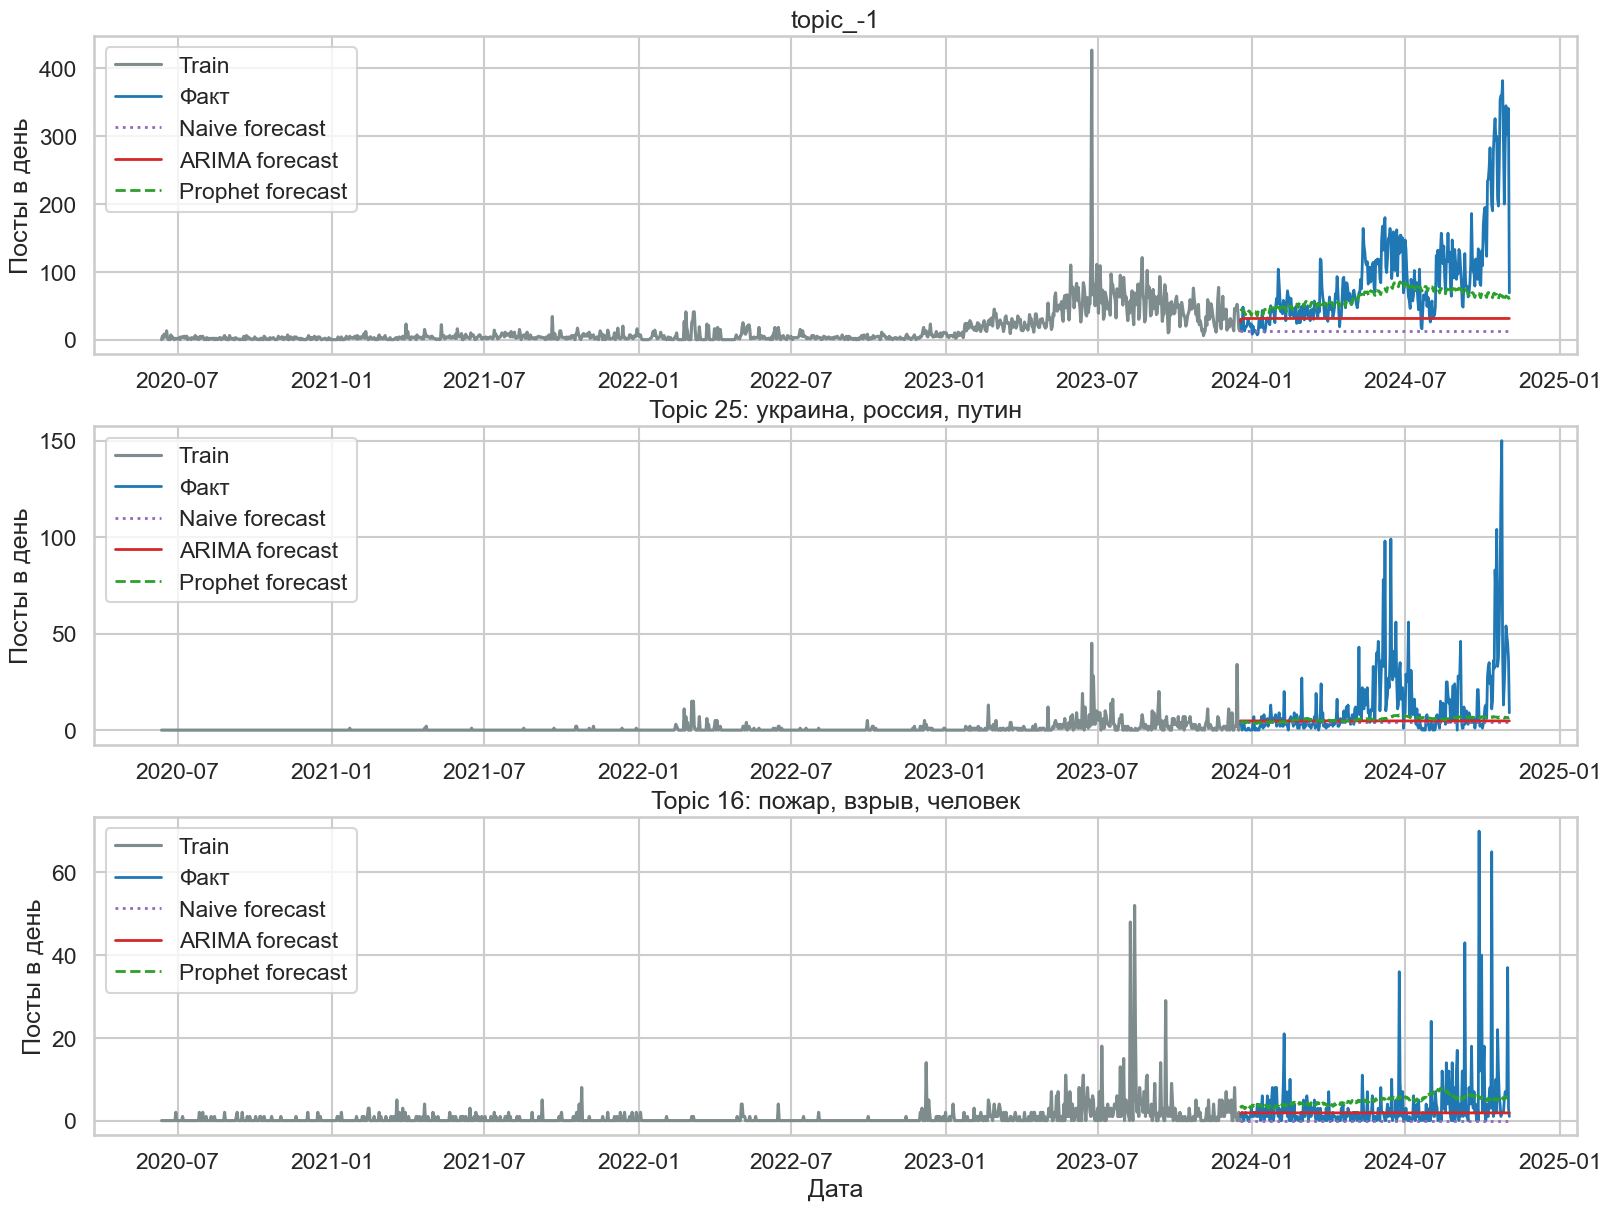

In [44]:

if not metrics_df.empty:
    topics_for_plot = top3_topics
    fig, axes = plt.subplots(len(topics_for_plot), 1, figsize=(16, 4 * len(topics_for_plot)), constrained_layout=True)
    if len(topics_for_plot) == 1:
        axes = [axes]

    for ax, col in zip(axes, topics_for_plot):
        train = forecast_store[(col, "Naive")]["train"]
        test = forecast_store[(col, "Naive")]["test"]
        ax.plot(train.index, train.values, label="Train", color="#7f8c8d")
        ax.plot(test.index, test.values, label="Факт", color="#1f77b4", linewidth=2)
        for model_name, color, style in [("Naive", "#9467bd", ":"), ("ARIMA", "#d62728", "-"), ("Prophet", "#2ca02c", "--")]:
            if (col, model_name) in forecast_store:
                pred = forecast_store[(col, model_name)]["pred"]
                ax.plot(test.index, pred, label=f"{model_name} forecast", color=color, linestyle=style, linewidth=2)
        ax.set_title(topic_lookup.get(col, col))
        ax.set_ylabel("Посты в день")
        ax.legend(loc="upper left")
    axes[-1].set_xlabel("Дата")
    plt.show()


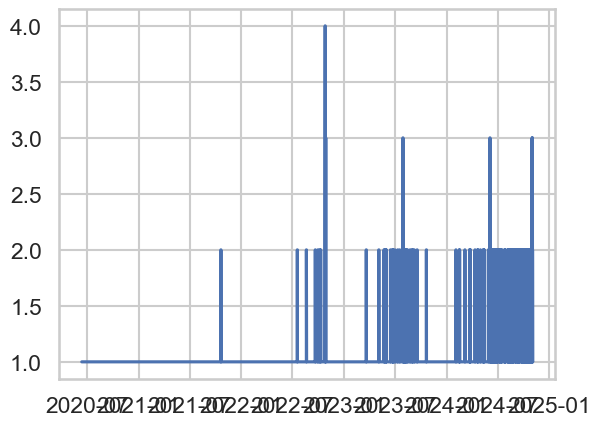

In [45]:
df.groupby('date').size()
plt.plot(df.groupby('date').size())

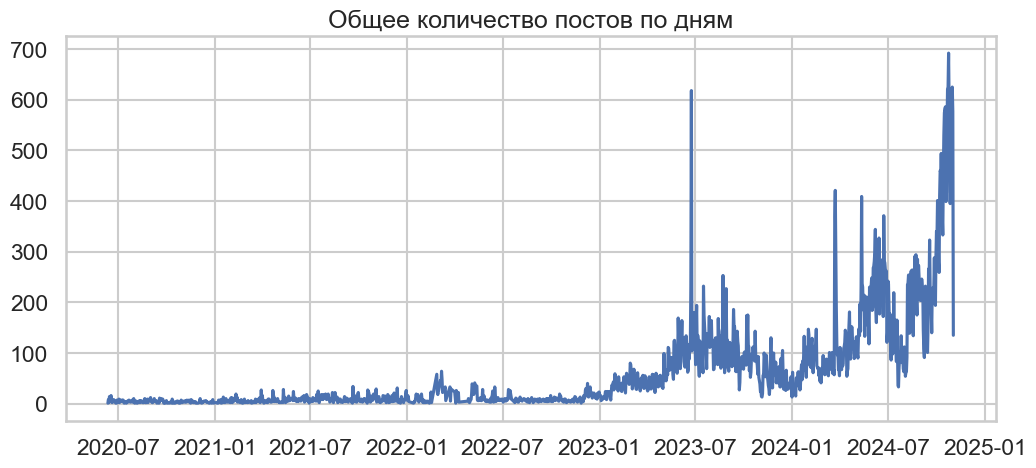

In [46]:
total_daily = df.groupby("day").size()
plt.figure(figsize=(12,5))
plt.plot(total_daily)
plt.title("Общее количество постов по дням")
plt.show()

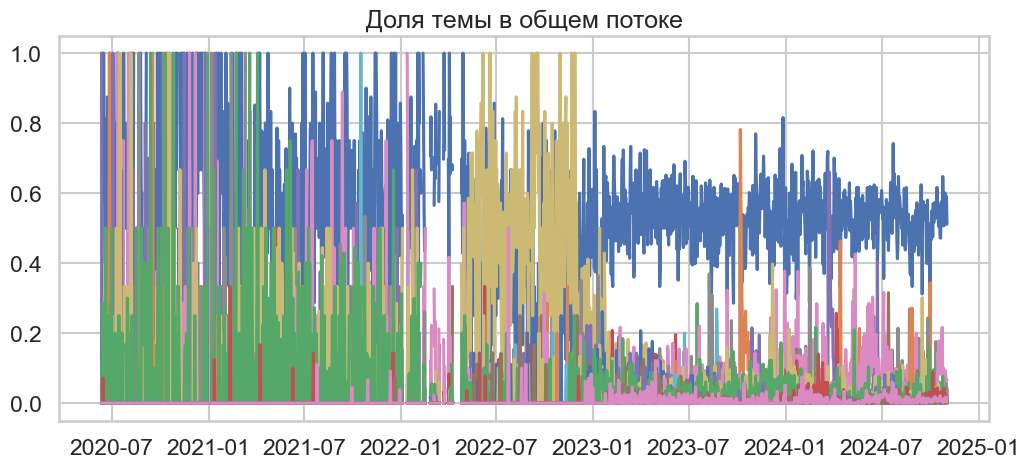

In [47]:
topic_share = topic_daily.div(total_daily, axis=0)
plt.figure(figsize=(12,5))
for col in topic_share.columns:
    plt.plot(topic_share.index, topic_share[col])
plt.title("Доля темы в общем потоке")
plt.show()


## Текстовый отчёт и сохранение результатов

Функция `generate_text_report()` собирает интерпретацию по темам, динамике, событиям, моделям и лидерам по активности. Затем результаты сохраняются в:
- `topics.csv`
- `time_series.csv`
- `metrics.csv`
- `report.txt`


In [48]:

def generate_text_report() -> str:
    lines = []
    lines.append("1. Темы")
    for topic_id in sorted(topic_terms):
        lines.append(f"Topic {topic_id}: {topic_name_map[topic_id]}")

    lines.append("")
    lines.append("2. Динамика")
    for _, row in trend_df.iterrows():
        lines.append(row["topic_name"])
        lines.append(f"- среднее значение: {row['mean_value']:.3f}")
        lines.append(f"- тренд: {row['trend']}")
        lines.append(f"- максимальный пик: {row['peak_date']}, {row['peak_value']}")

    lines.append("")
    lines.append("3. События")
    for topic_name, peak_group in peak_df.groupby("topic_name"):
        lines.append(topic_name)
        for _, row in peak_group.sort_values("peak_rank").iterrows():
            lines.append(f"- пик {int(row['peak_rank'])}: {row['peak_date']}, {row['peak_value']}")

    lines.append("")
    lines.append("4. Модели")
    for topic_name, topic_metrics in metrics_df.groupby("topic_name"):
        lines.append(topic_name)
        for model_name in ["ARIMA", "Prophet", "Naive"]:
            subset = topic_metrics.loc[topic_metrics["model"] == model_name]
            if not subset.empty:
                rmse = subset.iloc[0]["RMSE"]
                mae = subset.iloc[0]["MAE"]
                lines.append(f"- {model_name} RMSE: {rmse:.3f}; MAE: {mae:.3f}")
        best_model = topic_metrics.sort_values("RMSE").iloc[0]["model"]
        lines.append(f"- Лучшая модель: {best_model}")

    lines.append("")
    lines.append("5. ТОП тем")
    lines.append("Топ-3 темы по активности:")
    for rank, topic_col in enumerate(top3_topics, start=1):
        lines.append(f"{rank}. {topic_lookup.get(topic_col, topic_col)} — {int(topic_totals[topic_col])} публикаций")

    lines.append("")
    lines.append("6. Качество очистки")
    residual = noise_monitor.loc[(noise_monitor["clean_text"] > 0) | (noise_monitor["ners"] > 0)]
    if residual.empty:
        lines.append("- Контрольные телеграм-маркеры из clean_text удалены полностью.")
    else:
        lines.append("- В clean_text или ners ещё встречаются отдельные телеграм-маркеры:")
        for _, row in residual.iterrows():
            lines.append(f"  {row['term']}: clean_text={row['clean_text']}, ners={row['ners']}")

    return "\n".join(lines)


report_text = generate_text_report()
print(report_text[:4000])


1. Темы
Topic 0: израиль, хамас, израильский
Topic 1: луна, мкс, космический
Topic 2: протестовать, пашинян, ереван
Topic 3: махачкала, дербент, дагестан
Topic 4: трамп, байден, сша
Topic 5: самолёт, борт, аэропорт
Topic 6: курский, область, врио
Topic 7: тихорецкий, тихорецк, станица
Topic 8: пригожин, вагнер, чвк
Topic 9: украинский, украина, военный
Topic 10: путин, закон, указ
Topic 11: мост, крымский, крым
Topic 12: вода, человек, житель
Topic 13: госпитализировать, больница, актёр
Topic 14: пострадать, человек, погибнуть
Topic 15: белгород, белгородский, гладков
Topic 16: пожар, взрыв, человек
Topic 17: беспилотник, область, бпнуть
Topic 18: область, беспилотник, минобороны
Topic 19: противник, враг, дрон
Topic 20: противник, запорожский, направление
Topic 21: противник, направление, курский
Topic 22: всу, область, волчанск
Topic 23: крокус, теракт, холл
Topic 24: выборы, грузия, партия
Topic 25: украина, россия, путин
Topic 26: коронавирус, роспотребнадзор, вирус
Topic 27: госду

In [49]:

OUTPUT_DIR = Path(".")

topics_to_save = topic_summary.copy()
time_series_to_save = topic_daily.reset_index().rename(columns={"day": "date"})
metrics_to_save = metrics_df.sort_values(["topic_name", "model"]).reset_index(drop=True)
kmeans_topics_to_save = topic_artifacts["KMeans"]["topic_summary"].copy()
nmf_topics_to_save = topic_artifacts["NMF"]["topic_summary"].copy()

topics_to_save.to_csv(OUTPUT_DIR / "topics.csv", index=False)
time_series_to_save.to_csv(OUTPUT_DIR / "time_series.csv", index=False)
metrics_to_save.to_csv(OUTPUT_DIR / "metrics.csv", index=False)
kmeans_topics_to_save.to_csv(OUTPUT_DIR / "topics_kmeans.csv", index=False)
nmf_topics_to_save.to_csv(OUTPUT_DIR / "topics_nmf.csv", index=False)
topic_model_comparison.to_csv(OUTPUT_DIR / "topic_model_comparison.csv", index=False)
(OUTPUT_DIR / "report.txt").write_text(report_text, encoding="utf-8")

print("Сохранены файлы:")
print("- topics.csv")
print("- time_series.csv")
print("- metrics.csv")
print("- topics_kmeans.csv")
print("- topics_nmf.csv")
print("- topic_model_comparison.csv")
print("- report.txt")


Сохранены файлы:
- topics.csv
- time_series.csv
- metrics.csv
- topics_kmeans.csv
- topics_nmf.csv
- topic_model_comparison.csv
- report.txt
